In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('/Users/juanrios/Documents/master_thesis')
import importlib
from syntethic_data.syntethic_causal_data import SyntheticCausalSystem
from causal_discovery.causal_discovery import LiNGAMWithFCI, PCWithFCI, compare_with_ground_truth
from predictive_models.predictive_models import LGBMRegressor, NeuralNetRegressor, train_predictive_models, train_test_split
import explainability_models
from explainability_models import ShapleyExplainer, ShapleyFromScratch, AsymmetricShapley, ShapleyFlowWrapper, CausalShapley, TrueShapley
from utils.utils import visualize_causal_graph, visualize_comparison
import pandas as pd
import numpy as np

/Users/juanrios/Documents/master_thesis/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
%reload_ext autoreload

In [4]:
# General experiment variables
feats=10
sample=1000
parents_rate=0.6
y_column = 'Y'

# Linear system

No Confounders

In [5]:

file_path_no_confounders = f"linear_no_conf_low_conectivity_{int(feats*parents_rate)}_parents_{feats}_feats"

In [6]:
gen_linear_no_conf=SyntheticCausalSystem(n_features=feats,
                                random_state=42,
                                min_num_connected_edges=2,
                                edge_probability=0.1)
data, adj, conf = gen_linear_no_conf.generate_linear_system(n_samples=sample,
                                                    with_confounders=False,
                                                    noise_std=0.5,
                                                    y_parents_ratio=parents_rate)

data.to_parquet(f"../data/{file_path_no_confounders}.parquet")



In [7]:
lingam_fci = LiNGAMWithFCI(alpha=0.05,indep_test="fisherz")
pci_fci = PCWithFCI(alpha=0.5, indep_test="fisherz")
results_lingam = lingam_fci.get_causal_relationships(data)
results_pc = pci_fci.get_causal_relationships(data)

Running LiNGAM algorithm for causal structure discovery...
LiNGAM discovered 30 edges
Running FCI algorithm for confounder detection...


Depth=0, working on node 10: 100%|██████████| 11/11 [00:00<00:00, 2014.64it/s]


X8 --> X9
X8 --> X11
FCI detected 2 potential confounders pairs
 Running PC algorithm for causal structure discovery...


Depth=4, working on node 10: 100%|██████████| 11/11 [00:00<00:00, 5128.08it/s]


PC discovered 28 edges
 Running FCI algorithm for confounder detection...


Depth=0, working on node 10: 100%|██████████| 11/11 [00:00<00:00, 2366.14it/s]

X9 --> X7
X7 --> X11
FCI detected 3 potential confounders pairs


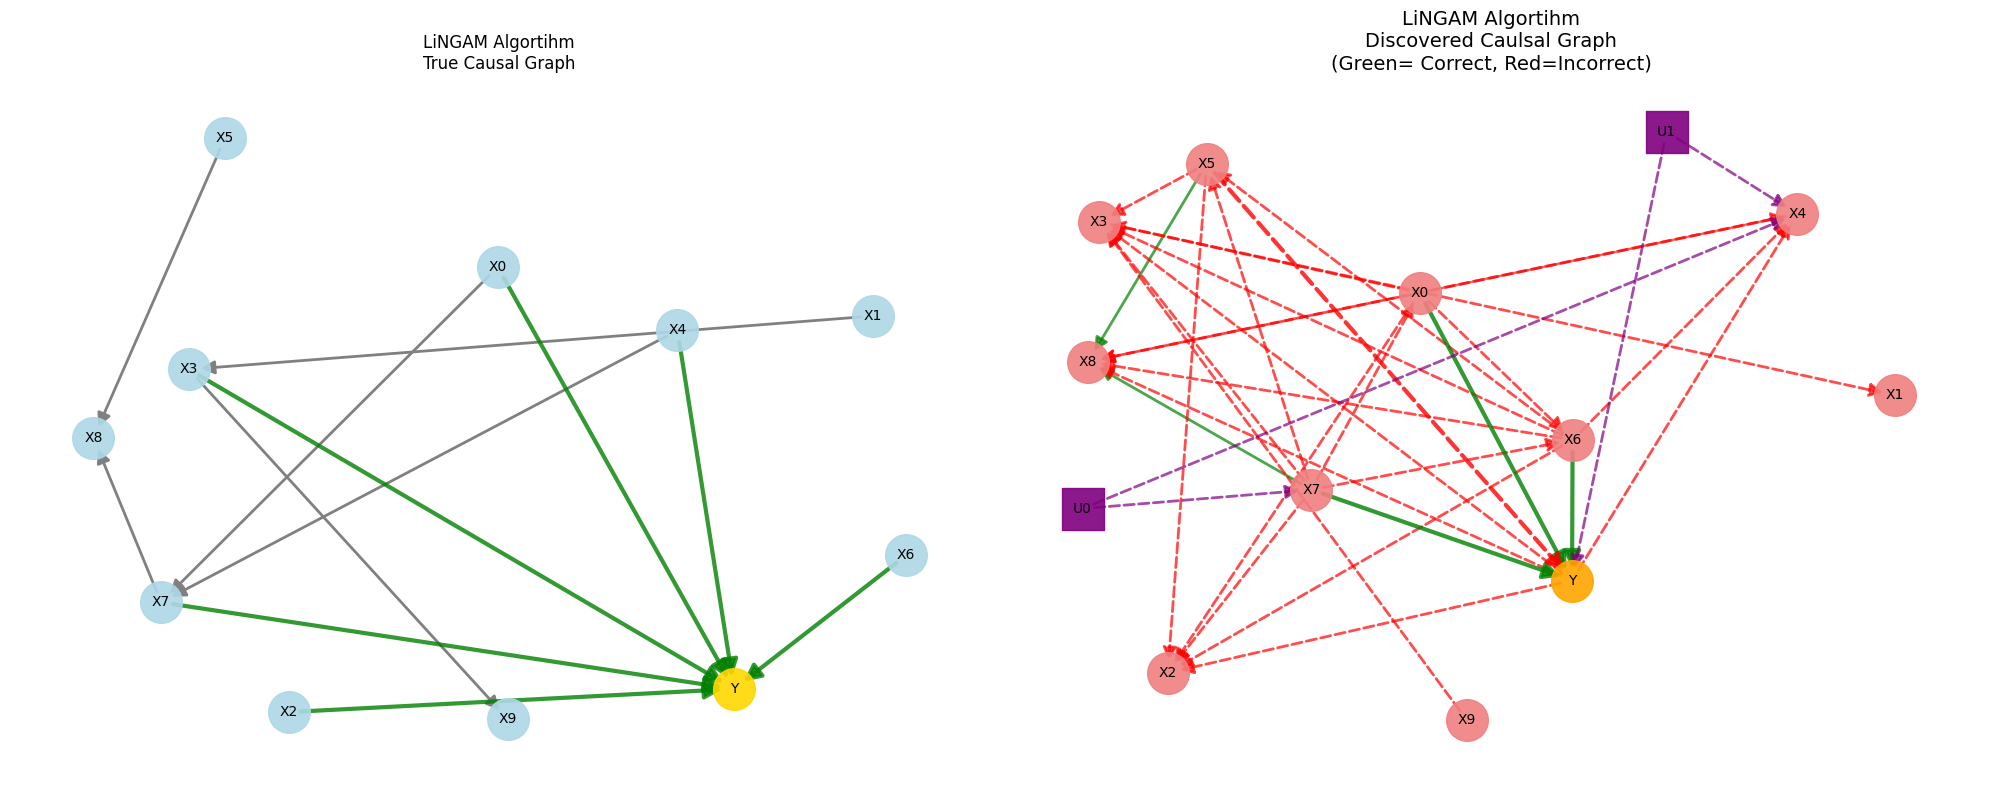

In [8]:
fig_lingam=visualize_comparison(true_adj=adj,
                     discovered_adj=results_lingam["adjacency_matrix"],
                     features_names=data.columns.tolist(),
                     y_parent_indices=gen_linear_no_conf.y_parent_indices,
                     true_confounders=conf,
                     discovered_confounders=results_lingam["confounders"],
                     title_preix='LiNGAM Algortihm'
                     )

In [9]:
compare_with_ground_truth( discovered_adj=results_lingam["adjacency_matrix"],
                              true_adj=adj,
                              discovered_confounders=results_lingam["confounders"],
                              true_confounders=conf)

{'true_positives': 5,
 'false_positives': 25,
 'false_negatives': 7,
 'true_negatives': 84,
 'precision': 0.16666666666666666,
 'recall': 0.4166666666666667,
 'f1_score': 0.23809523809523808,
 'structural_hamming_distance': 32,
 'n_true_edges': 12,
 'n_discovered_edges': 30,
 'n_true_confounders': 0,
 'n_discovered_confounders': 2}

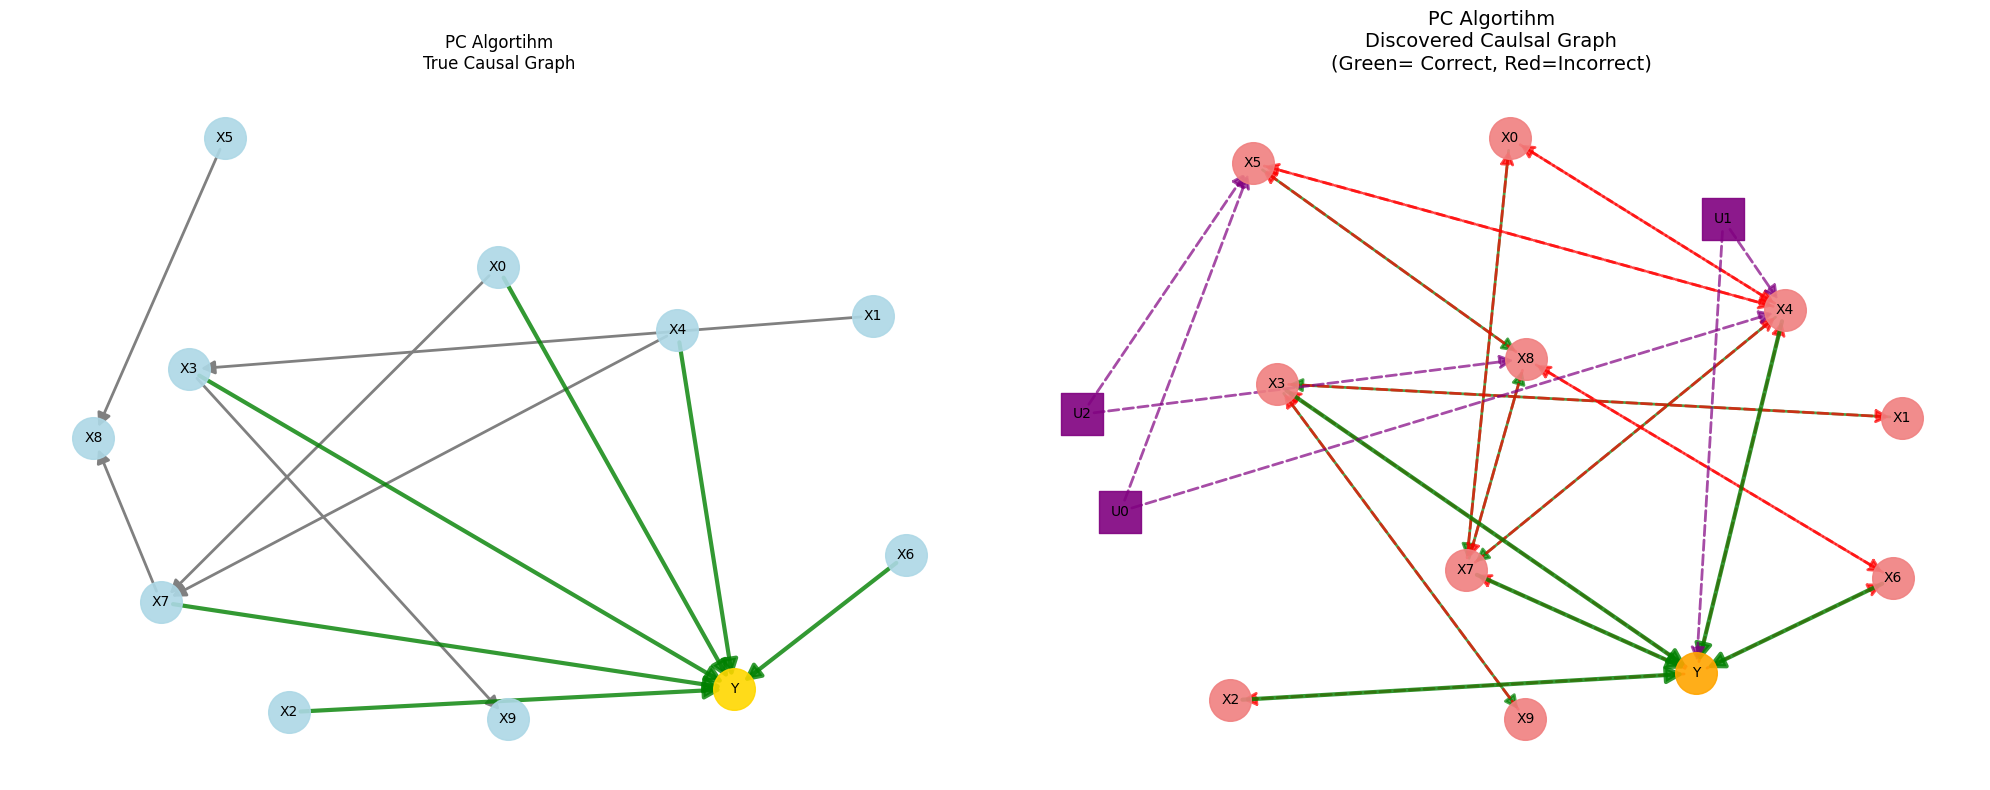

In [10]:
fig_pc=visualize_comparison(true_adj=adj,
                     discovered_adj=results_pc["adjacency_matrix"],
                     features_names=data.columns.tolist(),
                     y_parent_indices=gen_linear_no_conf.y_parent_indices,
                     true_confounders=conf,
                     discovered_confounders=results_pc["confounders"],
                     title_preix='PC Algortihm'
                     )

In [11]:
compare_with_ground_truth( discovered_adj=results_pc["adjacency_matrix"],
                              true_adj=adj,
                              discovered_confounders=results_pc["confounders"],
                              true_confounders=conf)

{'true_positives': 11,
 'false_positives': 17,
 'false_negatives': 1,
 'true_negatives': 92,
 'precision': 0.39285714285714285,
 'recall': 0.9166666666666666,
 'f1_score': 0.55,
 'structural_hamming_distance': 18,
 'n_true_edges': 12,
 'n_discovered_edges': 28,
 'n_true_confounders': 0,
 'n_discovered_confounders': 3}

# Model building step

In [12]:
no_confounder_linear_model = train_predictive_models(
    data,
    y_column='Y',
    models=["lgbm","nn"],
    features_selection=True,
    optimize=True,
    random_state=42
)

Training models to predict Y
Features: 10, Samples: 1000
[1/2] Training LightGBM Regressor
----------------------------------------------------------------------
Optimizing LightGBM hyperparameters (50 trials)...
Training LightGBM model...
[1/2] Training Neural Network Regressor
----------------------------------------------------------------------
Optimizing Neural Network hyperparameters (50 trials)...
dict_keys(['n_layers', 'hidden_dim_0', 'hidden_dim_1', 'alpha', 'learning_rate_init', 'batch_size', 'activation'])
Training Neural Network model...
      val_rmse   val_mae    val_r2   val_mse
lgbm  0.611443  0.489564  0.924977  0.373862
nn    0.557562  0.447633  0.937617  0.310875


In [13]:
lgbm_model= no_confounder_linear_model["models"]["lgbm"]
nn_model = no_confounder_linear_model["models"]["nn"]

In [14]:
lgbm_model.save(f"../models/{file_path_no_confounders}_lgbm")
nn_model.save(f"../models/{file_path_no_confounders}_nn")

LightGBM model saved to ../models/linear_no_conf_low_conectivity_6_parents_10_feats_lgbm.pkl
Neural Network model saved to ../models/linear_no_conf_low_conectivity_6_parents_10_feats_nn.pkl


In [15]:
# lgbm_loaded = LGBMRegressor.load(f"../models/{file_path_no_confounders}_lgbm")
# nn_loaded = NeuralNetRegressor.load(f"../models/{file_path_no_confounders}_nn")

# Shapley values Step

In [16]:
data.columns

Index(['X0', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'Y'], dtype='str')

In [17]:
X = data.drop(columns=[y_column])
y = data[y_column]
X_train, X_val, y_train, y_val =train_test_split(
            X, y, test_size=0.2, random_state=42
        )
train_size= X_train.shape[0]
test_size= X_val.shape[0]
background_data = X_train.sample(n=int(train_size*0.3), random_state=42)
test_instances = X_val.sample(n=int(test_size*0.5),random_state=42)

In [18]:
shap_explainer = ShapleyExplainer(lgbm_model.model, background_data, method='auto')
shap_values_library = shap_explainer.explain(test_instances)


Computing SHAP values using tree explainer...


In [19]:
scratch_explainer = ShapleyFromScratch(lgbm_model.model,background_data, n_samples=100,random_state=42)
shap_values_scratch = scratch_explainer.explain(test_instances,method='monte_carlo')

Computing Shapley values from scratch using monte_carlo method...
 Progress: 10/100 instances
 Progress: 20/100 instances
 Progress: 30/100 instances
 Progress: 40/100 instances
 Progress: 50/100 instances
 Progress: 60/100 instances
 Progress: 70/100 instances
 Progress: 80/100 instances
 Progress: 90/100 instances
 Progress: 100/100 instances


In [20]:
results_pc["adjacency_matrix"]

array([[ 0,  0,  0,  0, -1,  0,  0, -1,  0,  0,  0],
       [ 0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1],
       [ 0, -1,  0,  0,  0,  0,  0,  0,  0, -1, -1],
       [ 1,  0,  0,  0,  0,  1,  0,  1,  0,  0,  1],
       [ 0,  0,  0,  0, -1,  0,  0,  0, -1,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  1,  0, -1],
       [-1,  0,  0,  0, -1,  0,  0,  0, -1,  0, -1],
       [ 0,  0,  0,  0,  0,  1, -1,  1,  0,  0,  0],
       [ 0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  1,  1, -1,  0,  1,  1,  0,  0,  0]])

In [21]:

causal_graph , confounders = pci_fci.discover_structure(X)


 Running PC algorithm for causal structure discovery...


Depth=3, working on node 9: 100%|██████████| 10/10 [00:00<00:00, 3503.72it/s]


PC discovered 24 edges
 Running FCI algorithm for confounder detection...


Depth=0, working on node 9: 100%|██████████| 10/10 [00:00<00:00, 2691.24it/s]

X9 --> X7
FCI detected 2 potential confounders pairs


In [22]:
causal_graph

array([[ 0,  0,  0,  0, -1,  0,  0, -1,  0, -1],
       [ 0,  0,  0, -1,  0,  0, -1,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0, -1,  0,  0,  0,  0,  0,  0,  0, -1],
       [ 1,  0,  0,  0,  0,  1,  0,  1,  0,  1],
       [ 0,  0,  0,  0, -1,  0,  0,  0, -1,  0],
       [ 0,  1,  0,  0,  0,  0,  0,  0,  1,  0],
       [-1,  0,  0,  0, -1,  0,  0,  0, -1,  0],
       [ 0,  0,  0,  0,  0,  1, -1,  1,  0,  0],
       [-1,  0,  0, -1, -1,  0,  0,  0,  0,  0]])

In [23]:
asymmetric_explainer = AsymmetricShapley(lgbm_model.model, background_data, causal_graph=causal_graph,n_samples=100, random_sate=42,asymmetric_method='strict')
shap_values_asymmetric = asymmetric_explainer.explain(test_instances, method='exact')

Feature X0 has parents: []
Feature X1 has parents: []
Feature X2 has parents: []
Feature X3 has parents: []
Feature X4 has parents: ['X0', 'X9', 'X5', 'X7']
Feature X5 has parents: []
Feature X6 has parents: ['X8', 'X1']
Feature X7 has parents: []
Feature X8 has parents: ['X5', 'X7']
Feature X9 has parents: []
Topological order of features: [0, 1, 2, 3, 5, 7, 8, 6, 9, 4]
Using asymmetric method: strict
Computing Causal Shapley values using exact method...
Asymmetric sampling: strict
Respecting causal graph with 24 edges
 Progress: 10/100 instances
 Progress: 20/100 instances
 Progress: 30/100 instances
 Progress: 40/100 instances
 Progress: 50/100 instances
 Progress: 60/100 instances
 Progress: 70/100 instances
 Progress: 80/100 instances
 Progress: 90/100 instances
 Progress: 100/100 instances


In [24]:
background_data.columns

Index(['X0', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9'], dtype='str')

In [25]:
background_data_flow= X_train
background_data_flow['Y'] = y_train
background_data_flow.head()

,X0,X1,X2,X3,X4,X5,X6,X7,X8,X9,Y
29,-0.017265,0.031844,0.415426,0.862304,0.036966,0.719413,0.486953,-0.250482,2.179104,0.317391,0.410521
535,0.126378,0.067772,-0.326546,-0.242407,0.384623,-0.157438,-0.127725,-0.046146,0.118858,0.796745,-0.252750
695,0.052368,-0.547293,-0.102884,-0.637180,0.568770,0.108790,0.476380,-1.755883,2.076171,-0.972993,-2.560104
557,0.336129,0.075068,0.249883,0.382415,0.178861,0.192139,0.830547,-1.265310,1.447840,-0.074111,-0.471947
836,-0.246731,-0.089605,-0.277785,-0.408413,-0.815279,-0.953806,0.326917,2.254849,-2.039091,-0.348851,3.291015


In [26]:
test_instances['Y']=y_val.sample(n=int(test_size*0.5),random_state=42)

In [27]:
flow_explainer = ShapleyFlowWrapper(
                                    model=lgbm_model.model,
                                    background_data=background_data_flow,
                                    causal_graph = results_pc["adjacency_matrix"],
                                    y_index= 10,
                                    n_samples= 100,
                                    random_state=42)
shap_values_flow = flow_explainer.explain(test_instances)

ShapleyFlowWrapper initialized:
 Features: 11
 Y index: 10
 Source nodes: [0, 1, 2, 3, 5, 7, 9]
 Edges: 11
 Using on-manifold perturbation with condtional expectatiosn
Computing Shapley Flow for 100 instances...
Computing Shapley Flow with 100 trials...
 Total edge attributions: 2.116154
 Expected (f(x) - f(x')) : 1.426313
 Difference: 0.689840981300053using 100 samples to calculate f(x) and f(x')
 Relative error: 0.4837
Computing Shapley Flow with 100 trials...
 Total edge attributions: 6.783182
 Expected (f(x) - f(x')) : 6.799567
 Difference: 0.016385436111608698using 100 samples to calculate f(x) and f(x')
 Relative error: 0.0024
Computing Shapley Flow with 100 trials...
 Total edge attributions: -11.704163
 Expected (f(x) - f(x')) : -8.324415
 Difference: 3.379747769342499using 100 samples to calculate f(x) and f(x')
 Relative error: 0.4060
Computing Shapley Flow with 100 trials...
 Total edge attributions: -2.448556
 Expected (f(x) - f(x')) : -2.749813
 Difference: 0.3012574027626

In [28]:
true_shapley_explainer = TrueShapley( true_generator=gen_linear_no_conf.get_true_y_generator(), background_data=background_data, n_samples=100, random_state=42)
true_shapley_values = true_shapley_explainer.explain(test_instances)

Computing Shapley values from scratch using monte_carlo method...
 Progress: 10/100 instances
 Progress: 20/100 instances
 Progress: 30/100 instances
 Progress: 40/100 instances
 Progress: 50/100 instances
 Progress: 60/100 instances
 Progress: 70/100 instances
 Progress: 80/100 instances
 Progress: 90/100 instances
 Progress: 100/100 instances


In [29]:
%reload_ext autoreload

In [30]:
results_pc["confounders"]

[('X4', 'X5'), ('X4', 'Y'), ('X5', 'X8')]

In [31]:
causal_explainer=CausalShapley(model=lgbm_model.model,
                                               background_data=background_data,
                                               discovered_adj = causal_graph,
                                               discovered_conf = results_pc["confounders"],
                                               feature_names=[x for x in results_pc["feature_names"] if x != 'Y'],
                                               n_samples=100,
                                               random_state=42)

Initialized components
Components initialized
CausalShapleyPostInterventional Initialzied:
 Features: 10
 Components: 8 (in topological order)
 Component 0: features [5, 8, 4], CONFOUNDED, parents []
 Component 1: features [0], NON-CONFOUNDED, parents []
 Component 2: features [1], NON-CONFOUNDED, parents []
 Component 3: features [2], NON-CONFOUNDED, parents []
 Component 4: features [3], NON-CONFOUNDED, parents []
 Component 5: features [7], NON-CONFOUNDED, parents []
 Component 6: features [9], NON-CONFOUNDED, parents []
 Component 7: features [6], NON-CONFOUNDED, parents [1, 8]
 Outer samples (permutations): 100
 Inner samples (per coalition): 50


In [32]:
shap_values_causal = causal_explainer.explain(test_instances)

Computing Causal Shapley values (post-interventional sampling)...
    Permutations: 100
    Samples per coalition 50
 Progress: 10/100 instances
 Progress: 20/100 instances
 Progress: 30/100 instances
 Progress: 40/100 instances
 Progress: 50/100 instances
 Progress: 60/100 instances
 Progress: 70/100 instances
 Progress: 80/100 instances
 Progress: 90/100 instances
 Progress: 100/100 instances


In [33]:
true_shapley_values[0]

array([ 0.29310195, -0.01824069, -0.52874984, -0.38989883,  0.10756951,
       -0.01821365,  0.56048971,  0.6669308 ,  0.01315589,  0.01673622])

In [34]:
shap_values_causal[0]

array([-7.92765239e-03, -3.51768479e-02, -4.53911867e-01, -3.82128099e-01,
        2.29865243e-02,  5.13441329e-03,  5.61833175e-01,  7.05189775e-01,
        4.01481885e-02,  5.24245568e-04])

In [35]:
shap_values_library[0]

array([-0.00855029, -0.06083598, -0.46600799, -0.43563332,  0.06333986,
       -0.00358624,  0.628123  ,  0.74310407,  0.01271716, -0.00264211])

In [36]:
shap_values_scratch[0]

array([ 0.01198052, -0.05801662, -0.41298397, -0.3870339 ,  0.04883956,
       -0.00299783,  0.57720385,  0.66319509,  0.01100119,  0.00548396])

In [37]:
shap_values_asymmetric[0]

array([ 0.01108521, -0.01553608, -0.18230405, -0.15965656,  0.01393956,
       -0.00109539,  0.08959739,  0.16411474,  0.00081312, -0.00095609])

In [38]:
shap_values_flow[0]

array([ 0.62182809,  0.        , -0.50059119, -1.11790865,  0.        ,
       -0.00615659,  0.        ,  1.23712076,  1.88186181,  0.        ])

In [39]:
# Add causal post-interventional to comparisons
shap_flat_causal = shap_values_causal.flatten()
shap_flat_true = true_shapley_values.flatten()
shap_flat_library = shap_values_library.flatten()
shap_flat_scratch = shap_values_scratch.flatten()
shap_flat_asymmetric = shap_values_asymmetric.flatten()
shap_flat_flow = shap_values_flow.flatten()

In [40]:
correlation = np.corrcoef(shap_flat_library,shap_flat_scratch)[0,1]
correlation_true = np.corrcoef(shap_flat_true, shap_flat_scratch)[0,1]
correlation_scratch_asymmetric = np.corrcoef(shap_flat_scratch, shap_flat_asymmetric)[0,1]
correlation_scratch_flow = np.corrcoef(shap_flat_scratch, shap_flat_flow)[0,1]
correlation_causal = np.corrcoef(shap_flat_scratch, shap_flat_causal)[0,1]
mae = np.abs(shap_flat_library - shap_flat_scratch).mean()
mae_scr_asym = np.abs(shap_flat_asymmetric - shap_flat_scratch).mean()
mae_scr_fl = np.abs(shap_flat_flow - shap_flat_scratch).mean()
mae_causal = np.abs(shap_flat_causal - shap_flat_scratch).mean()
mae_true = np.abs(shap_flat_true - shap_flat_scratch).mean()

In [41]:
print(f" Correlation for shap values from library and scratch {correlation}")
print(f" Correlation for shap values from asymmetric and scratch {correlation_scratch_asymmetric}")
print(f" Correlation for shap values from flow and scratch {correlation_scratch_flow}")
print(f"Correlation for shap values from causal post and scratch {correlation_causal}")
print(f"Correlation for shap values from true and scratch {correlation_true}")

print(f"MAE for shap values from library and scratch {mae}")
print(f"MAE for shap values from asymmetric and scratch {mae_scr_asym}")
print(f"MAE for shap values from flow and scratch {mae_scr_fl}")
print(f"MAE for shap values from causal post and scratch {mae_causal}")
print(f"MAE for shap values from true and scratch {mae_true}")


 Correlation for shap values from library and scratch 0.9975768840394604
 Correlation for shap values from asymmetric and scratch 0.9592276525724593
 Correlation for shap values from flow and scratch 0.46809159027202085
Correlation for shap values from causal post and scratch 0.9988583816947133
Correlation for shap values from true and scratch 0.9449361103714744
MAE for shap values from library and scratch 0.03016374715462247
MAE for shap values from asymmetric and scratch 0.2472793808302809
MAE for shap values from flow and scratch 0.525287166980317
MAE for shap values from causal post and scratch 0.022347103440409705
MAE for shap values from true and scratch 0.11990539397261325


In [42]:
importance_library = shap_explainer.get_feature_importance()
importance_scratch = scratch_explainer.get_feature_importance()
importance_true = true_shapley_explainer.get_feature_importance()
importance_asymmetric = asymmetric_explainer.get_feature_importance()
importance_flow = flow_explainer.get_feature_importance()
importance_causal = causal_explainer.get_feature_importance()

In [43]:
importance_true

,feature,importance
7,X7,0.929134
3,X3,0.572589
6,X6,0.571540
4,X4,0.555328
0,X0,0.479632
2,X2,0.424881
9,X9,0.016633
1,X1,0.015024
5,X5,0.014308
8,X8,0.013266


In [44]:
importance_library

,feature,importance
7,X7,1.256161
6,X6,0.524409
3,X3,0.441228
4,X4,0.367156
2,X2,0.365437
0,X0,0.291657
9,X9,0.080589
1,X1,0.029810
8,X8,0.028629
5,X5,0.015150


In [45]:
importance_scratch

,feature,importance
7,X7,1.227689
6,X6,0.529286
3,X3,0.433595
4,X4,0.379775
2,X2,0.357543
0,X0,0.298669
9,X9,0.080058
1,X1,0.029370
8,X8,0.029268
5,X5,0.014854


In [46]:
importance_asymmetric

,feature,importance
7,X7,0.306246
3,X3,0.184101
2,X2,0.151877
0,X0,0.085325
6,X6,0.084343
4,X4,0.061528
9,X9,0.022808
1,X1,0.008201
5,X5,0.003333
8,X8,0.001826


In [47]:
importance_flow

,feature,importance
0,X7,1.609353
1,X8,1.348599
2,X0,0.654966
3,X3,0.552634
4,X2,0.541606
5,X5,0.247337
6,X1,0.000000
7,X4,0.000000
8,X6,0.000000
9,X9,0.000000


In [48]:
importance_causal

,feature,importance
7,X7,1.233715
6,X6,0.527628
3,X3,0.435370
4,X4,0.378094
2,X2,0.357717
0,X0,0.296227
9,X9,0.082988
1,X1,0.036124
8,X8,0.032769
5,X5,0.025538


Confounders present

In [49]:
file_path_confounders =f"linear_conf_low_conectivity_{int(feats*parents_rate)}_parents_{feats}_feats"

In [50]:

gen_linear_with_conf=SyntheticCausalSystem(n_features=feats,
                                random_state=42,
                                min_num_connected_edges=2,
                                edge_probability=0.1)
data, adj, conf = gen_linear_with_conf.generate_linear_system(n_samples=sample,
                                                    with_confounders=True,
                                                    noise_std=0.5,
                                                    y_parents_ratio=parents_rate)

data.to_parquet(f"../data/{file_path_confounders}.parquet")

In [51]:
lingam_fci = LiNGAMWithFCI(alpha=0.05,indep_test="fisherz")
pci_fci = PCWithFCI(alpha=0.5, indep_test="fisherz")
results_lingam = lingam_fci.get_causal_relationships(data)
results_pc = pci_fci.get_causal_relationships(data)

Running LiNGAM algorithm for causal structure discovery...
LiNGAM discovered 35 edges
Running FCI algorithm for confounder detection...


Depth=0, working on node 10: 100%|██████████| 11/11 [00:00<00:00, 2352.03it/s]


X2 --> X5
X5 --> X8
X9 --> X11
FCI detected 6 potential confounders pairs
 Running PC algorithm for causal structure discovery...


Depth=4, working on node 10: 100%|██████████| 11/11 [00:00<00:00, 4446.12it/s]


PC discovered 32 edges
 Running FCI algorithm for confounder detection...


Depth=0, working on node 10: 100%|██████████| 11/11 [00:00<00:00, 2709.18it/s]

X5 --> X8
X6 --> X11
X8 --> X9
X9 --> X11
FCI detected 6 potential confounders pairs


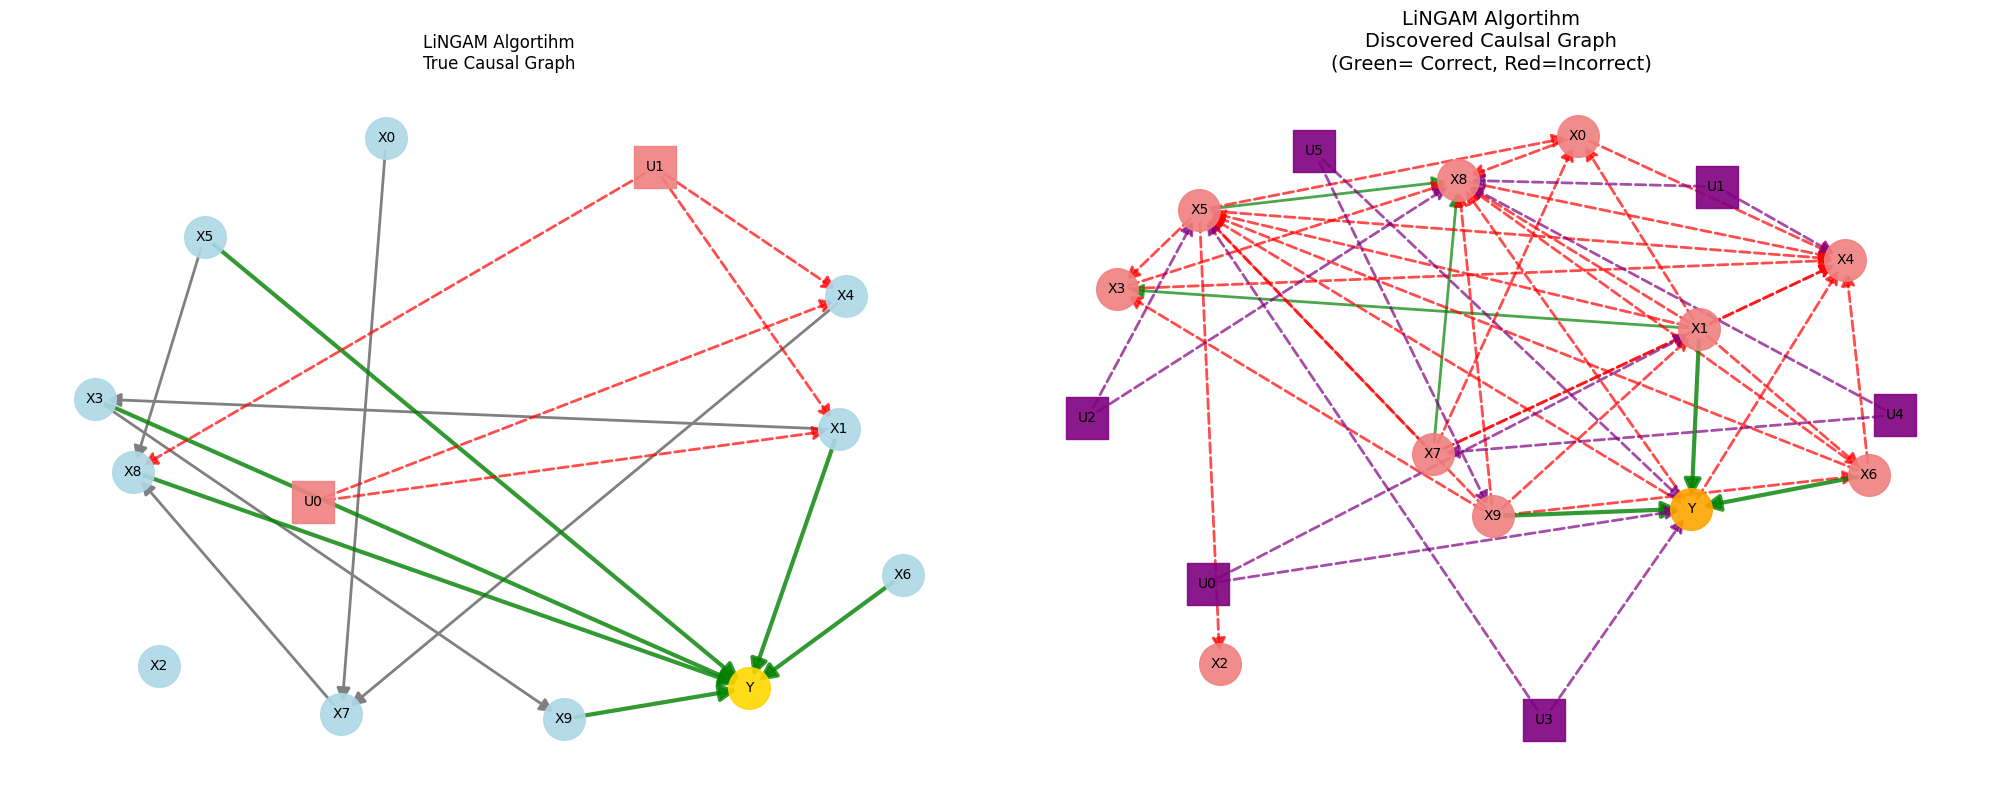

In [52]:
fig_lingam=visualize_comparison(true_adj=adj,
                     discovered_adj=results_lingam["adjacency_matrix"],
                     features_names=data.columns.tolist(),
                     y_parent_indices=gen_linear_with_conf.y_parent_indices,
                     true_confounders=conf,
                     discovered_confounders=results_lingam["confounders"],
                     title_preix='LiNGAM Algortihm'
                     )

In [53]:
compare_with_ground_truth( discovered_adj=results_lingam["adjacency_matrix"],
                              true_adj=adj,
                              discovered_confounders=results_lingam["confounders"],
                              true_confounders=conf)

{'true_positives': 6,
 'false_positives': 29,
 'false_negatives': 6,
 'true_negatives': 80,
 'precision': 0.17142857142857143,
 'recall': 0.5,
 'f1_score': 0.2553191489361702,
 'structural_hamming_distance': 35,
 'n_true_edges': 12,
 'n_discovered_edges': 35,
 'n_true_confounders': 2,
 'n_discovered_confounders': 6}

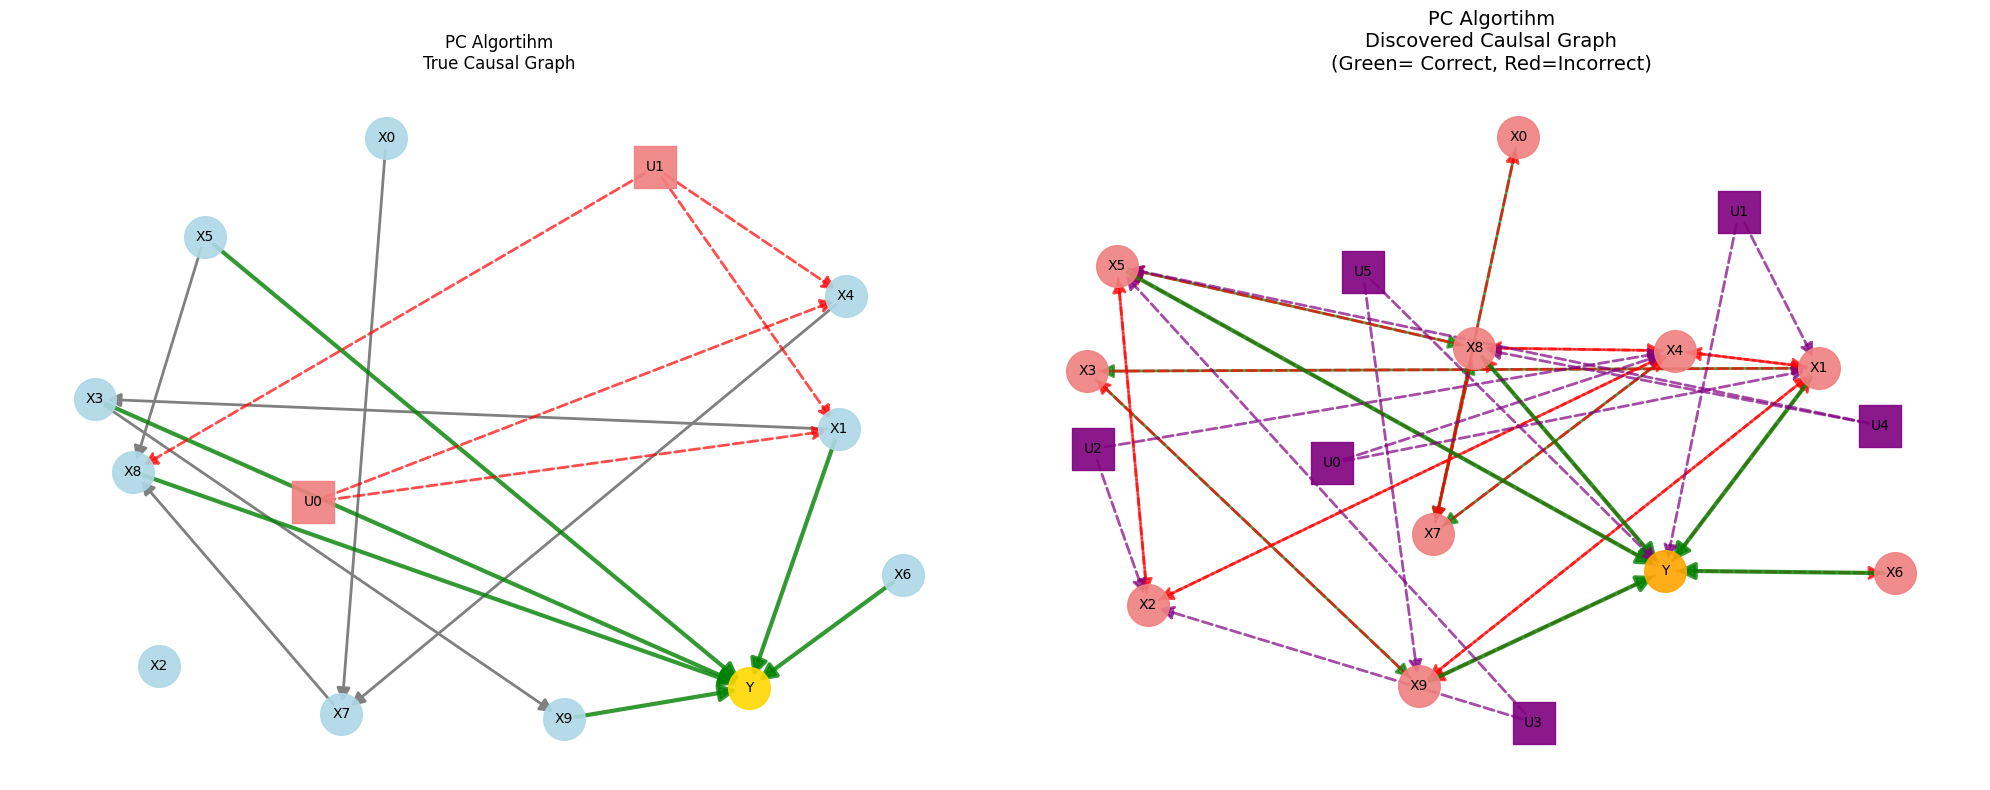

In [54]:
fig_pc=visualize_comparison(true_adj=adj,
                     discovered_adj=results_pc["adjacency_matrix"],
                     features_names=data.columns.tolist(),
                     y_parent_indices=gen_linear_with_conf.y_parent_indices,
                     true_confounders=conf,
                     discovered_confounders=results_pc["confounders"],
                     title_preix='PC Algortihm'
                     )

In [55]:
compare_with_ground_truth( discovered_adj=results_pc["adjacency_matrix"],
                              true_adj=adj,
                              discovered_confounders=results_pc["confounders"],
                              true_confounders=conf)

{'true_positives': 11,
 'false_positives': 21,
 'false_negatives': 1,
 'true_negatives': 88,
 'precision': 0.34375,
 'recall': 0.9166666666666666,
 'f1_score': 0.5,
 'structural_hamming_distance': 22,
 'n_true_edges': 12,
 'n_discovered_edges': 32,
 'n_true_confounders': 2,
 'n_discovered_confounders': 6}

# Model building step

In [56]:
confounder_linear_model = train_predictive_models(
    data,
    y_column='Y',
    models=["lgbm","nn"],
    features_selection=True,
    optimize=True,
    random_state=42
)

Training models to predict Y
Features: 10, Samples: 1000
[1/2] Training LightGBM Regressor
----------------------------------------------------------------------
Optimizing LightGBM hyperparameters (50 trials)...
Training LightGBM model...
[1/2] Training Neural Network Regressor
----------------------------------------------------------------------
Optimizing Neural Network hyperparameters (50 trials)...
dict_keys(['n_layers', 'hidden_dim_0', 'hidden_dim_1', 'alpha', 'learning_rate_init', 'batch_size', 'activation'])
Training Neural Network model...
      val_rmse   val_mae    val_r2   val_mse
lgbm  0.673787  0.525051  0.932372  0.453989
nn    0.526054  0.425420  0.958777  0.276732


In [57]:
lgbm_model= confounder_linear_model["models"]["lgbm"]
nn_model = confounder_linear_model["models"]["nn"]

In [58]:
lgbm_model.save(f"../models/{file_path_confounders}_lgbm")
nn_model.save(f"../models/{file_path_confounders}_nn")

LightGBM model saved to ../models/linear_conf_low_conectivity_6_parents_10_feats_lgbm.pkl
Neural Network model saved to ../models/linear_conf_low_conectivity_6_parents_10_feats_nn.pkl


## Shapley Values - Linear with Confounders

In [59]:
X = data.drop(columns=[y_column])
y = data[y_column]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
train_size = X_train.shape[0]
test_size = X_val.shape[0]
background_data = X_train.sample(n=int(train_size*0.3), random_state=42)
test_instances = X_val.sample(n=int(test_size*0.5), random_state=42)

In [60]:
# Standard SHAP from library
shap_explainer = ShapleyExplainer(lgbm_model.model, background_data, method='auto')
shap_values_library = shap_explainer.explain(test_instances)

# Shapley from scratch
scratch_explainer = ShapleyFromScratch(lgbm_model.model, background_data, n_samples=100, random_state=42)
shap_values_scratch = scratch_explainer.explain(test_instances, method='monte_carlo')

# Discover causal structure
causal_graph, confounders = pci_fci.discover_structure(X)

# Asymmetric Shapley
asymmetric_explainer = AsymmetricShapley(lgbm_model.model, background_data, causal_graph=causal_graph, n_samples=100, random_sate=42, asymmetric_method='strict')
shap_values_asymmetric = asymmetric_explainer.explain(test_instances, method='exact')

# Shapley Flow
background_data_flow = X_train.copy()
background_data_flow['Y'] = y_train
test_instances_flow = test_instances.copy()
test_instances_flow['Y'] = y_val.sample(n=int(test_size*0.5), random_state=42)

flow_explainer = ShapleyFlowWrapper(
    model=lgbm_model.model,
    background_data=background_data_flow,
    causal_graph=results_pc["adjacency_matrix"],
    y_index=10,
    n_samples=100,
    random_state=42
)
shap_values_flow = flow_explainer.explain(test_instances_flow)

# Causal Shapley (post-interventional)
causal_explainer = CausalShapley(
    model=lgbm_model.model,
    background_data=background_data,
    discovered_adj=causal_graph,
    discovered_conf=results_pc["confounders"],
    feature_names=[x for x in results_pc["feature_names"] if x != 'Y'],
    n_samples=100,
    random_state=42
)
shap_values_causal = causal_explainer.explain(test_instances)

# True Shapley (ground truth)
true_shapley_explainer = TrueShapley(
    true_generator=gen_linear_with_conf.get_true_y_generator(),
    background_data=background_data,
    n_samples=100,
    random_state=42
)
true_shapley_values = true_shapley_explainer.explain(test_instances)

Computing SHAP values using tree explainer...
Computing Shapley values from scratch using monte_carlo method...
 Progress: 10/100 instances
 Progress: 20/100 instances
 Progress: 30/100 instances
 Progress: 40/100 instances
 Progress: 50/100 instances
 Progress: 60/100 instances
 Progress: 70/100 instances
 Progress: 80/100 instances
 Progress: 90/100 instances
 Progress: 100/100 instances
 Running PC algorithm for causal structure discovery...


Depth=3, working on node 9: 100%|██████████| 10/10 [00:00<00:00, 4265.97it/s]


PC discovered 26 edges
 Running FCI algorithm for confounder detection...


Depth=0, working on node 9: 100%|██████████| 10/10 [00:00<00:00, 2752.71it/s]

X2 --> X4
X2 --> X9
X5 --> X8
FCI detected 6 potential confounders pairs
Feature X0 has parents: []
Feature X1 has parents: ['X9', 'X4']
Feature X2 has parents: ['X9', 'X4', 'X5']
Feature X3 has parents: ['X1', 'X9']
Feature X4 has parents: []
Feature X5 has parents: []
Feature X6 has parents: []
Feature X7 has parents: ['X0', 'X4']
Feature X8 has parents: ['X1', 'X4', 'X5', 'X7']
Feature X9 has parents: []
Topological order of features: [0, 4, 5, 6, 7, 9, 1, 2, 3, 8]
Using asymmetric method: strict
Computing Causal Shapley values using exact method...
Asymmetric sampling: strict
Respecting causal graph with 26 edges


 Progress: 10/100 instances
 Progress: 20/100 instances
 Progress: 30/100 instances
 Progress: 40/100 instances
 Progress: 50/100 instances
 Progress: 60/100 instances
 Progress: 70/100 instances
 Progress: 80/100 instances
 Progress: 90/100 instances
 Progress: 100/100 instances
ShapleyFlowWrapper initialized:
 Features: 11
 Y index: 10
 Source nodes: [0, 3, 4, 5, 6]
 Edges: 16
 Using on-manifold perturbation with condtional expectatiosn
Computing Shapley Flow for 100 instances...
Computing Shapley Flow with 100 trials...
 Total edge attributions: -0.544485
 Expected (f(x) - f(x')) : -0.019380
 Difference: 0.5251046081395548using 100 samples to calculate f(x) and f(x')
 Relative error: 27.0948
Computing Shapley Flow with 100 trials...
 Total edge attributions: -2.218698
 Expected (f(x) - f(x')) : 0.813024
 Difference: 3.0317217306169497using 100 samples to calculate f(x) and f(x')
 Relative error: 3.7289
Computing Shapley Flow with 100 trials...
 Total edge attributions: -5.465871
 Ex

In [61]:
# Flatten all Shapley values for comparison
shap_flat_library = shap_values_library.flatten()
shap_flat_scratch = shap_values_scratch.flatten()
shap_flat_asymmetric = shap_values_asymmetric.flatten()
shap_flat_flow = shap_values_flow.flatten()
shap_flat_causal = shap_values_causal.flatten()
shap_flat_true = true_shapley_values.flatten()

# Calculate correlations and MAE
correlation = np.corrcoef(shap_flat_library, shap_flat_scratch)[0,1]
correlation_asymmetric = np.corrcoef(shap_flat_scratch, shap_flat_asymmetric)[0,1]
correlation_flow = np.corrcoef(shap_flat_scratch, shap_flat_flow)[0,1]
correlation_causal = np.corrcoef(shap_flat_scratch, shap_flat_causal)[0,1]
correlation_true = np.corrcoef(shap_flat_true, shap_flat_scratch)[0,1]

mae = np.abs(shap_flat_library - shap_flat_scratch).mean()
mae_asymmetric = np.abs(shap_flat_asymmetric - shap_flat_scratch).mean()
mae_flow = np.abs(shap_flat_flow - shap_flat_scratch).mean()
mae_causal = np.abs(shap_flat_causal - shap_flat_scratch).mean()
mae_true = np.abs(shap_flat_true - shap_flat_scratch).mean()

print("Linear System with Confounders - Correlations vs Scratch:")
print(f"  Library:    {correlation:.4f}")
print(f"  Asymmetric: {correlation_asymmetric:.4f}")
print(f"  Flow:       {correlation_flow:.4f}")
print(f"  Causal:     {correlation_causal:.4f}")
print(f"  True:       {correlation_true:.4f}")
print("\nMAE vs Scratch:")
print(f"  Library:    {mae:.4f}")
print(f"  Asymmetric: {mae_asymmetric:.4f}")
print(f"  Flow:       {mae_flow:.4f}")
print(f"  Causal:     {mae_causal:.4f}")
print(f"  True:       {mae_true:.4f}")

Linear System with Confounders - Correlations vs Scratch:
  Library:    0.9932
  Asymmetric: 0.9209
  Flow:       0.1426
  Causal:     0.9933
  True:       0.9749

MAE vs Scratch:
  Library:    0.0574
  Asymmetric: 0.3369
  Flow:       0.8150
  Causal:     0.0508
  True:       0.1092


In [62]:
# Feature importance comparison
importance_library = shap_explainer.get_feature_importance()
importance_scratch = scratch_explainer.get_feature_importance()
importance_asymmetric = asymmetric_explainer.get_feature_importance()
importance_flow = flow_explainer.get_feature_importance()
importance_causal = causal_explainer.get_feature_importance()
importance_true = true_shapley_explainer.get_feature_importance()

print("Feature Importance Rankings:\n")
print("Library:\n", importance_library)
print("\nTrue (Ground Truth):\n", importance_true)
print("\nAsymmetric:\n", importance_asymmetric)
print("\nCausal:\n", importance_causal)

Feature Importance Rankings:

Library:
   feature  importance
8      X8    1.131883
6      X6    0.625744
9      X9    0.612989
5      X5    0.546126
1      X1    0.392103
3      X3    0.278256
7      X7    0.094480
2      X2    0.038825
0      X0    0.036892
4      X4    0.034131

True (Ground Truth):
   feature  importance
8      X8    1.261569
9      X9    0.987208
6      X6    0.678309
5      X5    0.561061
3      X3    0.519246
1      X1    0.460791
2      X2    0.021029
4      X4    0.019534
0      X0    0.017294
7      X7    0.017021

Asymmetric:
   feature  importance
6      X6    0.204783
8      X8    0.164210
9      X9    0.124464
5      X5    0.098272
3      X3    0.053560
1      X1    0.008820
2      X2    0.006796
0      X0    0.005652
4      X4    0.005214
7      X7    0.003732

Causal:
   feature  importance
8      X8    1.164512
9      X9    0.647632
6      X6    0.629894
5      X5    0.543990
1      X1    0.465836
3      X3    0.253257
7      X7    0.060853
0      X0  

## Shapley Values - Linear with Confounders

In [63]:
X = data.drop(columns=[y_column])
y = data[y_column]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
train_size = X_train.shape[0]
test_size = X_val.shape[0]
background_data = X_train.sample(n=int(train_size*0.3), random_state=42)
test_instances = X_val.sample(n=int(test_size*0.5), random_state=42)

In [64]:
# Standard SHAP from library
shap_explainer = ShapleyExplainer(lgbm_model.model, background_data, method='auto')
shap_values_library = shap_explainer.explain(test_instances)

Computing SHAP values using tree explainer...


In [65]:
# Shapley from scratch
scratch_explainer = ShapleyFromScratch(lgbm_model.model, background_data, n_samples=100, random_state=42)
shap_values_scratch = scratch_explainer.explain(test_instances, method='monte_carlo')

Computing Shapley values from scratch using monte_carlo method...
 Progress: 10/100 instances
 Progress: 20/100 instances
 Progress: 30/100 instances
 Progress: 40/100 instances
 Progress: 50/100 instances
 Progress: 60/100 instances
 Progress: 70/100 instances
 Progress: 80/100 instances
 Progress: 90/100 instances
 Progress: 100/100 instances


In [66]:
# Discover causal structure
causal_graph, confounders = pci_fci.discover_structure(X)

 Running PC algorithm for causal structure discovery...


Depth=3, working on node 9: 100%|██████████| 10/10 [00:00<00:00, 4313.80it/s]


PC discovered 26 edges
 Running FCI algorithm for confounder detection...


Depth=0, working on node 9: 100%|██████████| 10/10 [00:00<00:00, 2823.31it/s]

X2 --> X4
X2 --> X9
X5 --> X8
FCI detected 6 potential confounders pairs


In [67]:
# Asymmetric Shapley
asymmetric_explainer = AsymmetricShapley(lgbm_model.model, background_data, causal_graph=causal_graph, n_samples=100, random_sate=42, asymmetric_method='strict')
shap_values_asymmetric = asymmetric_explainer.explain(test_instances, method='exact')

Feature X0 has parents: []
Feature X1 has parents: ['X9', 'X4']
Feature X2 has parents: ['X9', 'X4', 'X5']
Feature X3 has parents: ['X1', 'X9']
Feature X4 has parents: []
Feature X5 has parents: []
Feature X6 has parents: []
Feature X7 has parents: ['X0', 'X4']
Feature X8 has parents: ['X1', 'X4', 'X5', 'X7']
Feature X9 has parents: []
Topological order of features: [0, 4, 5, 6, 7, 9, 1, 2, 3, 8]
Using asymmetric method: strict
Computing Causal Shapley values using exact method...
Asymmetric sampling: strict
Respecting causal graph with 26 edges
 Progress: 10/100 instances
 Progress: 20/100 instances
 Progress: 30/100 instances
 Progress: 40/100 instances
 Progress: 50/100 instances
 Progress: 60/100 instances
 Progress: 70/100 instances
 Progress: 80/100 instances
 Progress: 90/100 instances
 Progress: 100/100 instances


In [68]:
# Shapley Flow
background_data_flow = X_train.copy()
background_data_flow['Y'] = y_train
test_instances_flow = test_instances.copy()
test_instances_flow['Y'] = y_val.sample(n=int(test_size*0.5), random_state=42)

flow_explainer = ShapleyFlowWrapper(
    model=lgbm_model.model,
    background_data=background_data_flow,
    causal_graph=results_pc["adjacency_matrix"],
    y_index=10,
    n_samples=100,
    random_state=42
)
shap_values_flow = flow_explainer.explain(test_instances_flow)

ShapleyFlowWrapper initialized:
 Features: 11
 Y index: 10
 Source nodes: [0, 3, 4, 5, 6]
 Edges: 16
 Using on-manifold perturbation with condtional expectatiosn
Computing Shapley Flow for 100 instances...
Computing Shapley Flow with 100 trials...
 Total edge attributions: -0.544485
 Expected (f(x) - f(x')) : -0.019380
 Difference: 0.5251046081395548using 100 samples to calculate f(x) and f(x')
 Relative error: 27.0948
Computing Shapley Flow with 100 trials...
 Total edge attributions: -2.218698
 Expected (f(x) - f(x')) : 0.813024
 Difference: 3.0317217306169497using 100 samples to calculate f(x) and f(x')
 Relative error: 3.7289
Computing Shapley Flow with 100 trials...
 Total edge attributions: -5.465871
 Expected (f(x) - f(x')) : -3.142694
 Difference: 2.323177358358587using 100 samples to calculate f(x) and f(x')
 Relative error: 0.7392
Computing Shapley Flow with 100 trials...
 Total edge attributions: 7.092606
 Expected (f(x) - f(x')) : 3.653726
 Difference: 3.4388804379609605usi

In [69]:
# Causal Shapley (post-interventional)
causal_explainer = CausalShapley(
    model=lgbm_model.model,
    background_data=background_data,
    discovered_adj=causal_graph,
    discovered_conf=results_pc["confounders"],
    feature_names=[x for x in results_pc["feature_names"] if x != 'Y'],
    n_samples=100,
    random_state=42
)
shap_values_causal = causal_explainer.explain(test_instances)

Initialized components
Components initialized
CausalShapleyPostInterventional Initialzied:
 Features: 10
 Components: 6 (in topological order)
 Component 0: features [4, 5, 1, 2, 8], CONFOUNDED, parents []
 Component 1: features [0], NON-CONFOUNDED, parents []
 Component 2: features [6], NON-CONFOUNDED, parents []
 Component 3: features [9], NON-CONFOUNDED, parents []
 Component 4: features [7], NON-CONFOUNDED, parents [0, 4]
 Component 5: features [3], NON-CONFOUNDED, parents [1, 9]
 Outer samples (permutations): 100
 Inner samples (per coalition): 50
Computing Causal Shapley values (post-interventional sampling)...
    Permutations: 100
    Samples per coalition 50
 Progress: 10/100 instances
 Progress: 20/100 instances
 Progress: 30/100 instances
 Progress: 40/100 instances
 Progress: 50/100 instances
 Progress: 60/100 instances
 Progress: 70/100 instances
 Progress: 80/100 instances
 Progress: 90/100 instances
 Progress: 100/100 instances


In [70]:
# True Shapley (ground truth)
true_shapley_explainer = TrueShapley(
    true_generator=gen_linear_with_conf.get_true_y_generator(),
    background_data=background_data,
    n_samples=100,
    random_state=42
)
true_shapley_values = true_shapley_explainer.explain(test_instances)

Computing Shapley values from scratch using monte_carlo method...
 Progress: 10/100 instances
 Progress: 20/100 instances
 Progress: 30/100 instances
 Progress: 40/100 instances
 Progress: 50/100 instances
 Progress: 60/100 instances
 Progress: 70/100 instances
 Progress: 80/100 instances
 Progress: 90/100 instances
 Progress: 100/100 instances


In [71]:
# Flatten all Shapley values for comparison
shap_flat_library = shap_values_library.flatten()
shap_flat_scratch = shap_values_scratch.flatten()
shap_flat_asymmetric = shap_values_asymmetric.flatten()
shap_flat_flow = shap_values_flow.flatten()
shap_flat_causal = shap_values_causal.flatten()
shap_flat_true = true_shapley_values.flatten()

In [72]:
# Calculate correlations and MAE
correlation = np.corrcoef(shap_flat_library, shap_flat_scratch)[0,1]
correlation_asymmetric = np.corrcoef(shap_flat_scratch, shap_flat_asymmetric)[0,1]
correlation_flow = np.corrcoef(shap_flat_scratch, shap_flat_flow)[0,1]
correlation_causal = np.corrcoef(shap_flat_scratch, shap_flat_causal)[0,1]
correlation_true = np.corrcoef(shap_flat_true, shap_flat_scratch)[0,1]

mae = np.abs(shap_flat_library - shap_flat_scratch).mean()
mae_asymmetric = np.abs(shap_flat_asymmetric - shap_flat_scratch).mean()
mae_flow = np.abs(shap_flat_flow - shap_flat_scratch).mean()
mae_causal = np.abs(shap_flat_causal - shap_flat_scratch).mean()
mae_true = np.abs(shap_flat_true - shap_flat_scratch).mean()

print("Linear System with Confounders - Correlations vs Scratch:")
print(f"  Library:    {correlation:.4f}")
print(f"  Asymmetric: {correlation_asymmetric:.4f}")
print(f"  Flow:       {correlation_flow:.4f}")
print(f"  Causal:     {correlation_causal:.4f}")
print(f"  True:       {correlation_true:.4f}")
print("\nMAE vs Scratch:")
print(f"  Library:    {mae:.4f}")
print(f"  Asymmetric: {mae_asymmetric:.4f}")
print(f"  Flow:       {mae_flow:.4f}")
print(f"  Causal:     {mae_causal:.4f}")
print(f"  True:       {mae_true:.4f}")

Linear System with Confounders - Correlations vs Scratch:
  Library:    0.9932
  Asymmetric: 0.9209
  Flow:       0.1426
  Causal:     0.9933
  True:       0.9749

MAE vs Scratch:
  Library:    0.0574
  Asymmetric: 0.3369
  Flow:       0.8150
  Causal:     0.0508
  True:       0.1092


In [73]:
# Feature importance comparison
importance_library = shap_explainer.get_feature_importance()
importance_scratch = scratch_explainer.get_feature_importance()
importance_asymmetric = asymmetric_explainer.get_feature_importance()
importance_flow = flow_explainer.get_feature_importance()
importance_causal = causal_explainer.get_feature_importance()
importance_true = true_shapley_explainer.get_feature_importance()

print("Feature Importance Rankings:\n")
print("Library:\n", importance_library)
print("\nTrue (Ground Truth):\n", importance_true)
print("\nAsymmetric:\n", importance_asymmetric)
print("\nCausal:\n", importance_causal)

Feature Importance Rankings:

Library:
   feature  importance
8      X8    1.131883
6      X6    0.625744
9      X9    0.612989
5      X5    0.546126
1      X1    0.392103
3      X3    0.278256
7      X7    0.094480
2      X2    0.038825
0      X0    0.036892
4      X4    0.034131

True (Ground Truth):
   feature  importance
8      X8    1.261569
9      X9    0.987208
6      X6    0.678309
5      X5    0.561061
3      X3    0.519246
1      X1    0.460791
2      X2    0.021029
4      X4    0.019534
0      X0    0.017294
7      X7    0.017021

Asymmetric:
   feature  importance
6      X6    0.204783
8      X8    0.164210
9      X9    0.124464
5      X5    0.098272
3      X3    0.053560
1      X1    0.008820
2      X2    0.006796
0      X0    0.005652
4      X4    0.005214
7      X7    0.003732

Causal:
   feature  importance
8      X8    1.164512
9      X9    0.647632
6      X6    0.629894
5      X5    0.543990
1      X1    0.465836
3      X3    0.253257
7      X7    0.060853
0      X0  

# Non-linear data

No confounders present

In [74]:
file_path_no_confounders = f"no_linear_no_conf_low_conectivity_{int(feats*parents_rate)}_parents_{feats}_feats"

In [75]:
gen_no_linear_no_conf=SyntheticCausalSystem(n_features=feats,
                                random_state=42,
                                min_num_connected_edges=2,
                                edge_probability=0.1)
data, adj, conf = gen_no_linear_no_conf.generate_nonlinear_system(n_samples=sample,
                                                    with_confounders=False,
                                                    noise_std=0.5,
                                                    y_parents_ratio=parents_rate)

data.to_parquet(f"../data/{file_path_no_confounders}.parquet")

In [76]:
lingam_fci = LiNGAMWithFCI(alpha=0.05,indep_test="fisherz")
pci_fci = PCWithFCI(alpha=0.5, indep_test="fisherz")
results_lingam = lingam_fci.get_causal_relationships(data)
results_pc = pci_fci.get_causal_relationships(data)

Running LiNGAM algorithm for causal structure discovery...
LiNGAM discovered 19 edges
Running FCI algorithm for confounder detection...


Depth=0, working on node 10: 100%|██████████| 11/11 [00:00<00:00, 2132.63it/s]


X8 --> X9
X9 --> X11
FCI detected 3 potential confounders pairs
 Running PC algorithm for causal structure discovery...


Depth=5, working on node 10: 100%|██████████| 11/11 [00:00<00:00, 4137.14it/s]


PC discovered 46 edges
 Running FCI algorithm for confounder detection...


Depth=0, working on node 10: 100%|██████████| 11/11 [00:00<00:00, 2736.98it/s]

X8 --> X9
X9 --> X11
FCI detected 15 potential confounders pairs


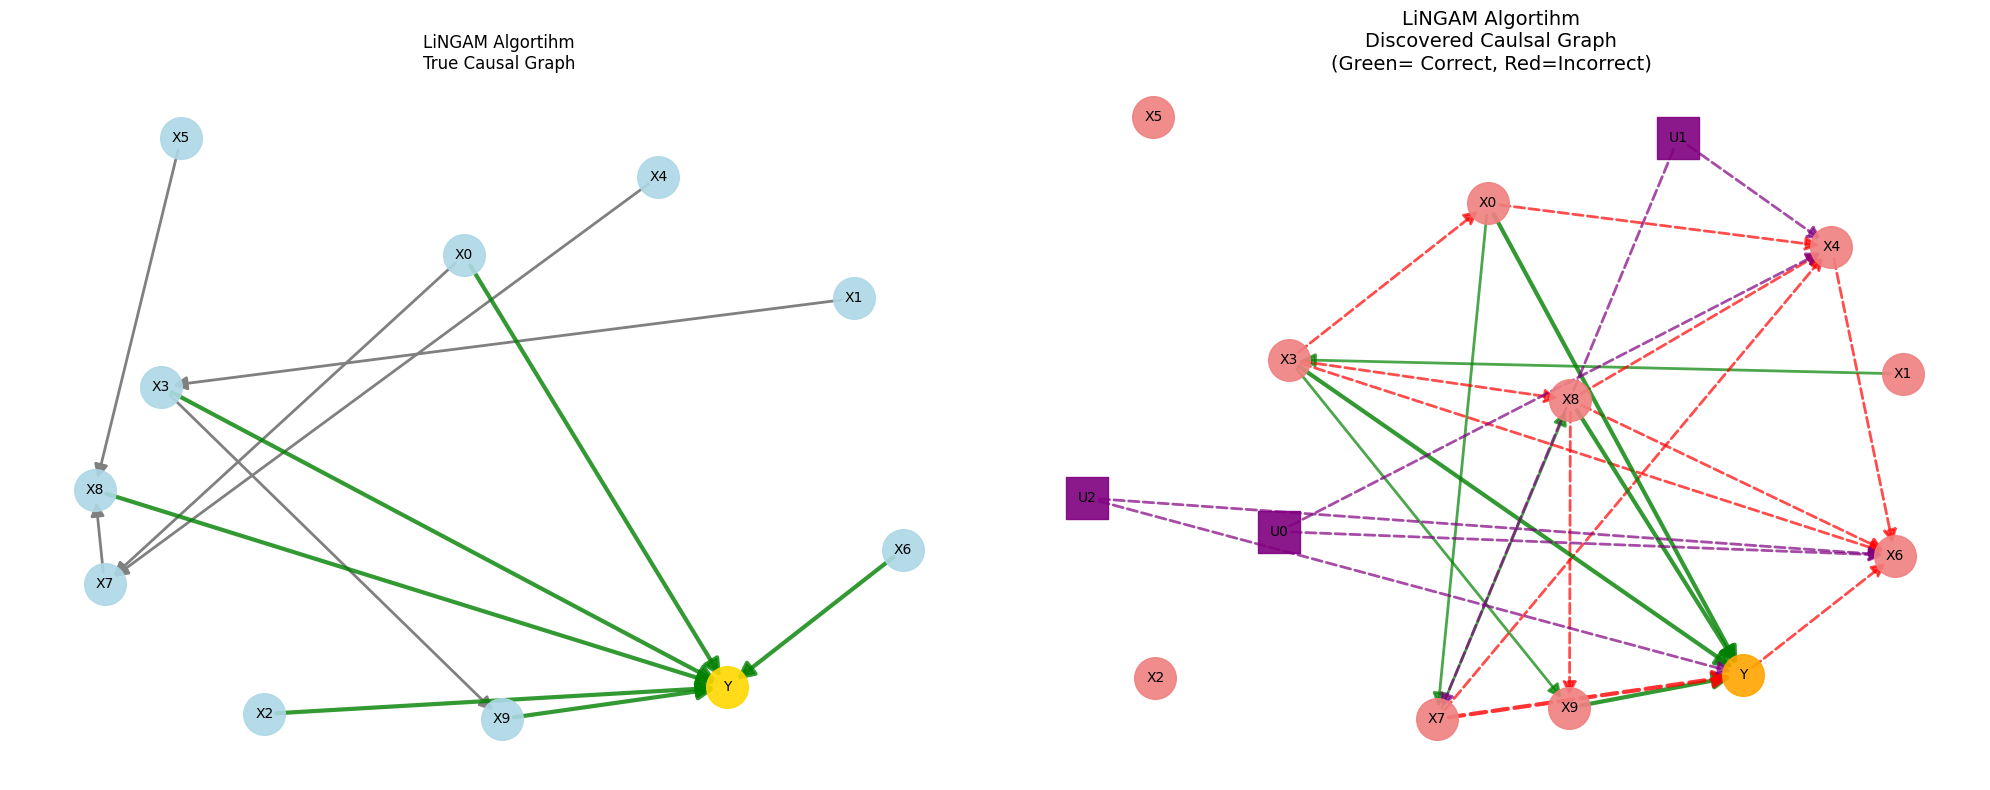

In [77]:
fig_lingam=visualize_comparison(true_adj=adj,
                     discovered_adj=results_lingam["adjacency_matrix"],
                     features_names=data.columns.tolist(),
                     y_parent_indices=gen_no_linear_no_conf.y_parent_indices,
                     true_confounders=conf,
                     discovered_confounders=results_lingam["confounders"],
                     title_preix='LiNGAM Algortihm'
                     )

In [78]:
compare_with_ground_truth( discovered_adj=results_lingam["adjacency_matrix"],
                              true_adj=adj,
                              discovered_confounders=results_lingam["confounders"],
                              true_confounders=conf)

{'true_positives': 8,
 'false_positives': 11,
 'false_negatives': 4,
 'true_negatives': 98,
 'precision': 0.42105263157894735,
 'recall': 0.6666666666666666,
 'f1_score': 0.5161290322580646,
 'structural_hamming_distance': 15,
 'n_true_edges': 12,
 'n_discovered_edges': 19,
 'n_true_confounders': 0,
 'n_discovered_confounders': 3}

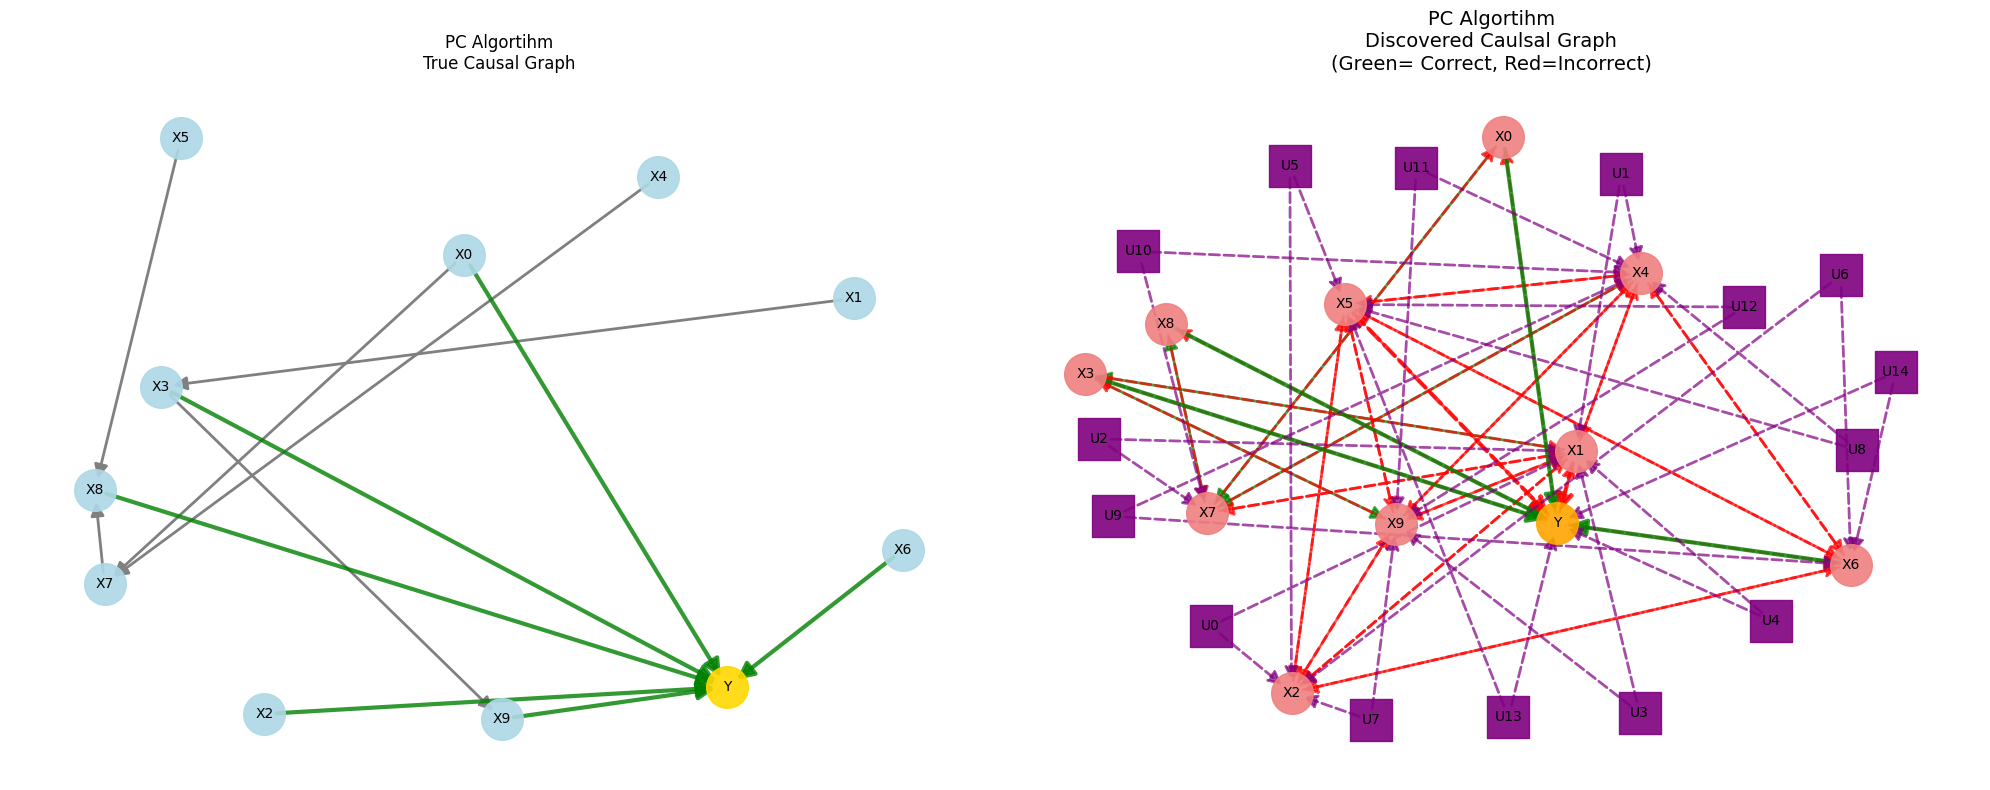

In [79]:
fig_pc=visualize_comparison(true_adj=adj,
                     discovered_adj=results_pc["adjacency_matrix"],
                     features_names=data.columns.tolist(),
                     y_parent_indices=gen_no_linear_no_conf.y_parent_indices,
                     true_confounders=conf,
                     discovered_confounders=results_pc["confounders"],
                     title_preix='PC Algortihm'
                     )

In [80]:
compare_with_ground_truth( discovered_adj=results_pc["adjacency_matrix"],
                              true_adj=adj,
                              discovered_confounders=results_pc["confounders"],
                              true_confounders=conf)

{'true_positives': 9,
 'false_positives': 37,
 'false_negatives': 3,
 'true_negatives': 72,
 'precision': 0.1956521739130435,
 'recall': 0.75,
 'f1_score': 0.3103448275862069,
 'structural_hamming_distance': 40,
 'n_true_edges': 12,
 'n_discovered_edges': 46,
 'n_true_confounders': 0,
 'n_discovered_confounders': 15}

# Model building step

In [81]:
no_confounder_linear_model = train_predictive_models(
    data,
    y_column='Y',
    models=["lgbm","nn"],
    features_selection=True,
    optimize=True,
    random_state=42
)

Training models to predict Y
Features: 10, Samples: 1000
[1/2] Training LightGBM Regressor
----------------------------------------------------------------------
Optimizing LightGBM hyperparameters (50 trials)...
Training LightGBM model...
[1/2] Training Neural Network Regressor
----------------------------------------------------------------------
Optimizing Neural Network hyperparameters (50 trials)...
dict_keys(['n_layers', 'hidden_dim_0', 'hidden_dim_1', 'alpha', 'learning_rate_init', 'batch_size', 'activation'])
Training Neural Network model...
      val_rmse   val_mae    val_r2   val_mse
lgbm  0.565322  0.437516  0.725972  0.319589
nn    0.596171  0.469604  0.695250  0.355420


In [82]:
lgbm_model= no_confounder_linear_model["models"]["lgbm"]
nn_model = no_confounder_linear_model["models"]["nn"]

In [83]:
lgbm_model.save(f"../models/{file_path_no_confounders}_lgbm")
nn_model.save(f"../models/{file_path_no_confounders}_nn")

LightGBM model saved to ../models/no_linear_no_conf_low_conectivity_6_parents_10_feats_lgbm.pkl
Neural Network model saved to ../models/no_linear_no_conf_low_conectivity_6_parents_10_feats_nn.pkl


## Shapley Values - Nonlinear without Confounders

In [84]:
X = data.drop(columns=[y_column])
y = data[y_column]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
train_size = X_train.shape[0]
test_size = X_val.shape[0]
background_data = X_train.sample(n=int(train_size*0.3), random_state=42)
test_instances = X_val.sample(n=int(test_size*0.5), random_state=42)

# All explainers
shap_explainer = ShapleyExplainer(lgbm_model.model, background_data, method='auto')
shap_values_library = shap_explainer.explain(test_instances)

scratch_explainer = ShapleyFromScratch(lgbm_model.model, background_data, n_samples=100, random_state=42)
shap_values_scratch = scratch_explainer.explain(test_instances, method='monte_carlo')

causal_graph, confounders = pci_fci.discover_structure(X)

asymmetric_explainer = AsymmetricShapley(lgbm_model.model, background_data, causal_graph=causal_graph, n_samples=100, random_sate=42, asymmetric_method='strict')
shap_values_asymmetric = asymmetric_explainer.explain(test_instances, method='exact')

background_data_flow = X_train.copy()
background_data_flow['Y'] = y_train
test_instances_flow = test_instances.copy()
test_instances_flow['Y'] = y_val.sample(n=int(test_size*0.5), random_state=42)

flow_explainer = ShapleyFlowWrapper(model=lgbm_model.model, background_data=background_data_flow, causal_graph=results_pc["adjacency_matrix"], y_index=10, n_samples=100, random_state=42)
shap_values_flow = flow_explainer.explain(test_instances_flow)

causal_explainer = CausalShapley(model=lgbm_model.model, background_data=background_data, discovered_adj=causal_graph, discovered_conf=results_pc["confounders"], feature_names=[x for x in results_pc["feature_names"] if x != 'Y'], n_samples=100, random_state=42)
shap_values_causal = causal_explainer.explain(test_instances)

true_shapley_explainer = TrueShapley(true_generator=gen_no_linear_no_conf.get_true_y_generator(), background_data=background_data, n_samples=100, random_state=42)
true_shapley_values = true_shapley_explainer.explain(test_instances)

# Comparisons
shap_flat_library = shap_values_library.flatten()
shap_flat_scratch = shap_values_scratch.flatten()
shap_flat_asymmetric = shap_values_asymmetric.flatten()
shap_flat_flow = shap_values_flow.flatten()
shap_flat_causal = shap_values_causal.flatten()
shap_flat_true = true_shapley_values.flatten()

print("Nonlinear System (No Confounders) - Correlations vs Scratch:")
print(f"  Library:    {np.corrcoef(shap_flat_library, shap_flat_scratch)[0,1]:.4f}")
print(f"  Asymmetric: {np.corrcoef(shap_flat_scratch, shap_flat_asymmetric)[0,1]:.4f}")
print(f"  Flow:       {np.corrcoef(shap_flat_scratch, shap_flat_flow)[0,1]:.4f}")
print(f"  Causal:     {np.corrcoef(shap_flat_scratch, shap_flat_causal)[0,1]:.4f}")
print(f"  True:       {np.corrcoef(shap_flat_true, shap_flat_scratch)[0,1]:.4f}")
print("\nMAE vs Scratch:")
print(f"  Library:    {np.abs(shap_flat_library - shap_flat_scratch).mean():.4f}")
print(f"  Asymmetric: {np.abs(shap_flat_asymmetric - shap_flat_scratch).mean():.4f}")
print(f"  Flow:       {np.abs(shap_flat_flow - shap_flat_scratch).mean():.4f}")
print(f"  Causal:     {np.abs(shap_flat_causal - shap_flat_scratch).mean():.4f}")
print(f"  True:       {np.abs(shap_flat_true - shap_flat_scratch).mean():.4f}")

Computing SHAP values using tree explainer...
Computing Shapley values from scratch using monte_carlo method...
 Progress: 10/100 instances
 Progress: 20/100 instances
 Progress: 30/100 instances
 Progress: 40/100 instances
 Progress: 50/100 instances
 Progress: 60/100 instances
 Progress: 70/100 instances
 Progress: 80/100 instances
 Progress: 90/100 instances
 Progress: 100/100 instances
 Running PC algorithm for causal structure discovery...


Depth=4, working on node 9: 100%|██████████| 10/10 [00:00<00:00, 3706.53it/s]


PC discovered 36 edges
 Running FCI algorithm for confounder detection...


Depth=0, working on node 9: 100%|██████████| 10/10 [00:00<00:00, 2781.00it/s]

X9 --> X6
X8 --> X9
FCI detected 12 potential confounders pairs
Feature X0 has parents: []
Feature X1 has parents: ['X2', 'X3', 'X4', 'X7', 'X9']
Feature X2 has parents: ['X9', 'X6']
Feature X3 has parents: []
Feature X4 has parents: ['X9', 'X5', 'X6', 'X7']
Feature X5 has parents: ['X8', 'X9', 'X2', 'X6']
Feature X6 has parents: []
Feature X7 has parents: []
Feature X8 has parents: []
Feature X9 has parents: []
Topological order of features: [0, 3, 6, 7, 8, 9, 2, 5, 4, 1]
Using asymmetric method: strict
Computing Causal Shapley values using exact method...
Asymmetric sampling: strict
Respecting causal graph with 36 edges


 Progress: 10/100 instances
 Progress: 20/100 instances
 Progress: 30/100 instances
 Progress: 40/100 instances
 Progress: 50/100 instances
 Progress: 60/100 instances
 Progress: 70/100 instances
 Progress: 80/100 instances
 Progress: 90/100 instances
 Progress: 100/100 instances
ShapleyFlowWrapper initialized:
 Features: 11
 Y index: 10
 Source nodes: [0, 3, 6, 7, 8, 9]
 Edges: 20
 Using on-manifold perturbation with condtional expectatiosn
Computing Shapley Flow for 100 instances...
Computing Shapley Flow with 100 trials...
 Total edge attributions: -0.497273
 Expected (f(x) - f(x')) : 0.014577
 Difference: 0.511850614357734using 100 samples to calculate f(x) and f(x')
 Relative error: 35.1129
Computing Shapley Flow with 100 trials...
 Total edge attributions: -2.086358
 Expected (f(x) - f(x')) : -1.132580
 Difference: 0.9537784882091094using 100 samples to calculate f(x) and f(x')
 Relative error: 0.8421
Computing Shapley Flow with 100 trials...
 Total edge attributions: -3.807351
 

Confounders present

In [85]:
file_path_confounders = f"no_linear_conf_low_conectivity_{int(feats*parents_rate)}_parents_{feats}_feats"

In [86]:
gen_no_linear_conf=SyntheticCausalSystem(n_features=feats,
                                random_state=42,
                                min_num_connected_edges=2,
                                edge_probability=0.1)
data, adj, conf = gen_no_linear_conf.generate_nonlinear_system(n_samples=sample,
                                                    with_confounders=True,
                                                    noise_std=0.5,
                                                    y_parents_ratio=parents_rate)
data.to_parquet(f"../data/{file_path_confounders}.parquet")

In [87]:
lingam_fci = LiNGAMWithFCI(alpha=0.05,indep_test="fisherz")
pci_fci = PCWithFCI(alpha=0.5, indep_test="fisherz")
results_lingam = lingam_fci.get_causal_relationships(data)
results_pc = pci_fci.get_causal_relationships(data)

Running LiNGAM algorithm for causal structure discovery...
LiNGAM discovered 7 edges
Running FCI algorithm for confounder detection...


Depth=0, working on node 10: 100%|██████████| 11/11 [00:00<00:00, 2257.65it/s]


FCI detected 2 potential confounders pairs
 Running PC algorithm for causal structure discovery...


Depth=4, working on node 10: 100%|██████████| 11/11 [00:00<00:00, 5042.88it/s]


PC discovered 38 edges
 Running FCI algorithm for confounder detection...


Depth=0, working on node 10: 100%|██████████| 11/11 [00:00<00:00, 2617.72it/s]

X1 --> X5
X8 --> X11
FCI detected 15 potential confounders pairs


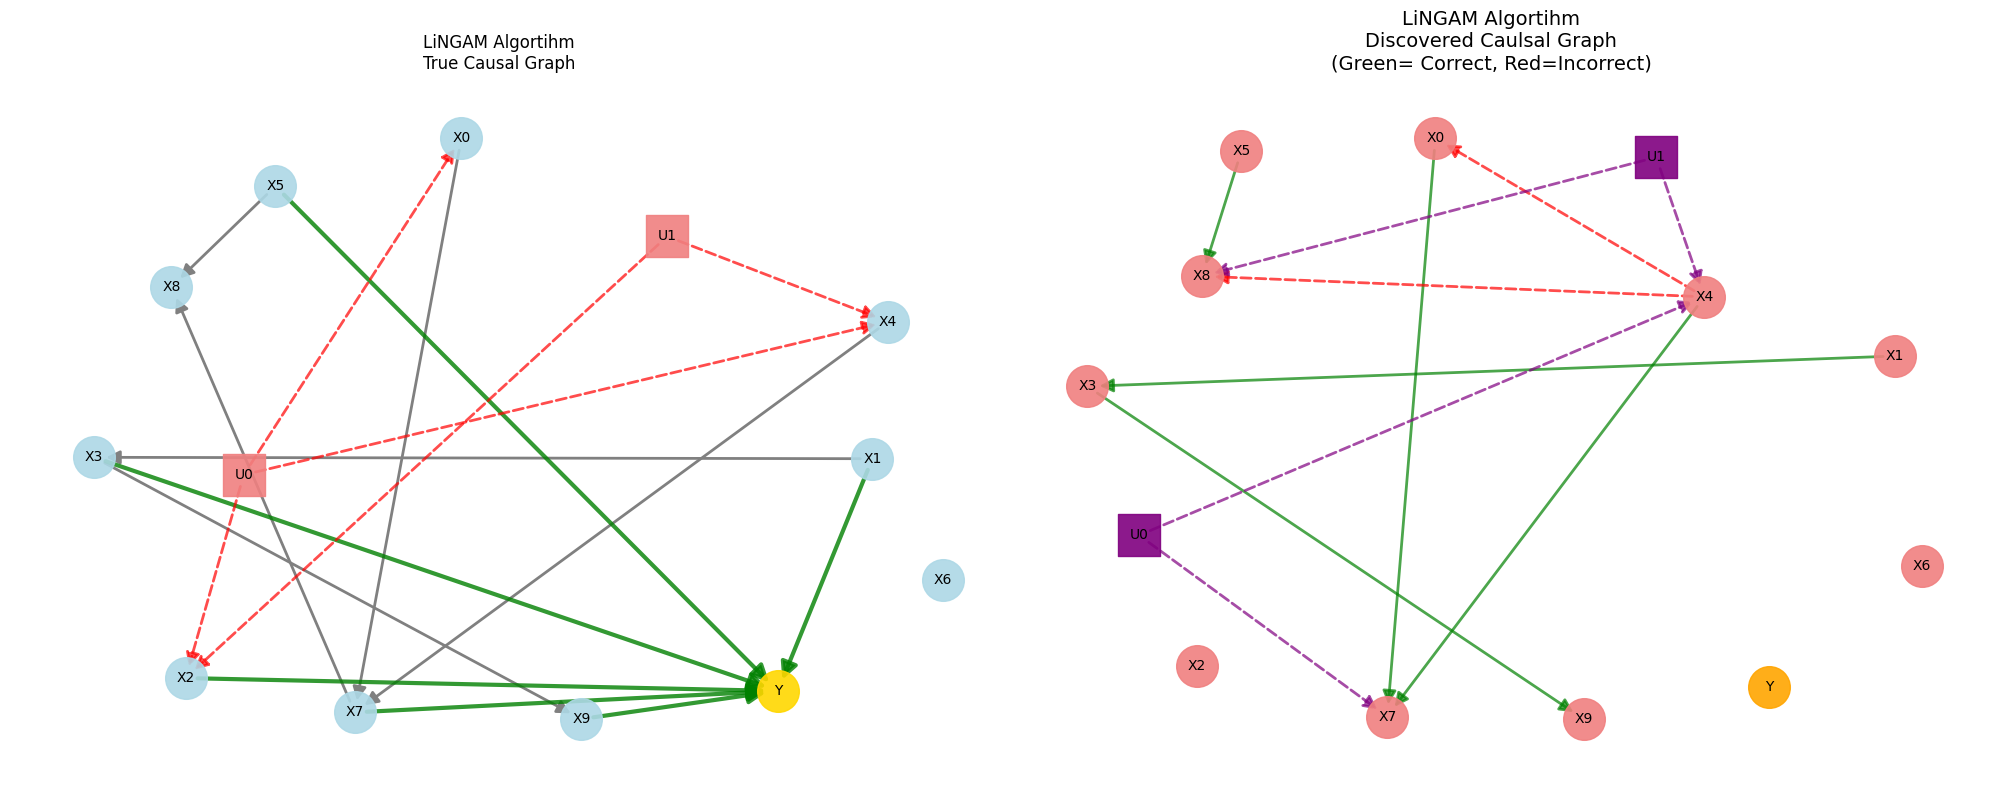

In [88]:
fig_lingam=visualize_comparison(true_adj=adj,
                     discovered_adj=results_lingam["adjacency_matrix"],
                     features_names=data.columns.tolist(),
                     y_parent_indices=gen_no_linear_conf.y_parent_indices,
                     true_confounders=conf,
                     discovered_confounders=results_lingam["confounders"],
                     title_preix='LiNGAM Algortihm'
                     )

In [89]:
compare_with_ground_truth( discovered_adj=results_lingam["adjacency_matrix"],
                              true_adj=adj,
                              discovered_confounders=results_lingam["confounders"],
                              true_confounders=conf)

{'true_positives': 5,
 'false_positives': 2,
 'false_negatives': 7,
 'true_negatives': 107,
 'precision': 0.7142857142857143,
 'recall': 0.4166666666666667,
 'f1_score': 0.5263157894736842,
 'structural_hamming_distance': 9,
 'n_true_edges': 12,
 'n_discovered_edges': 7,
 'n_true_confounders': 2,
 'n_discovered_confounders': 2}

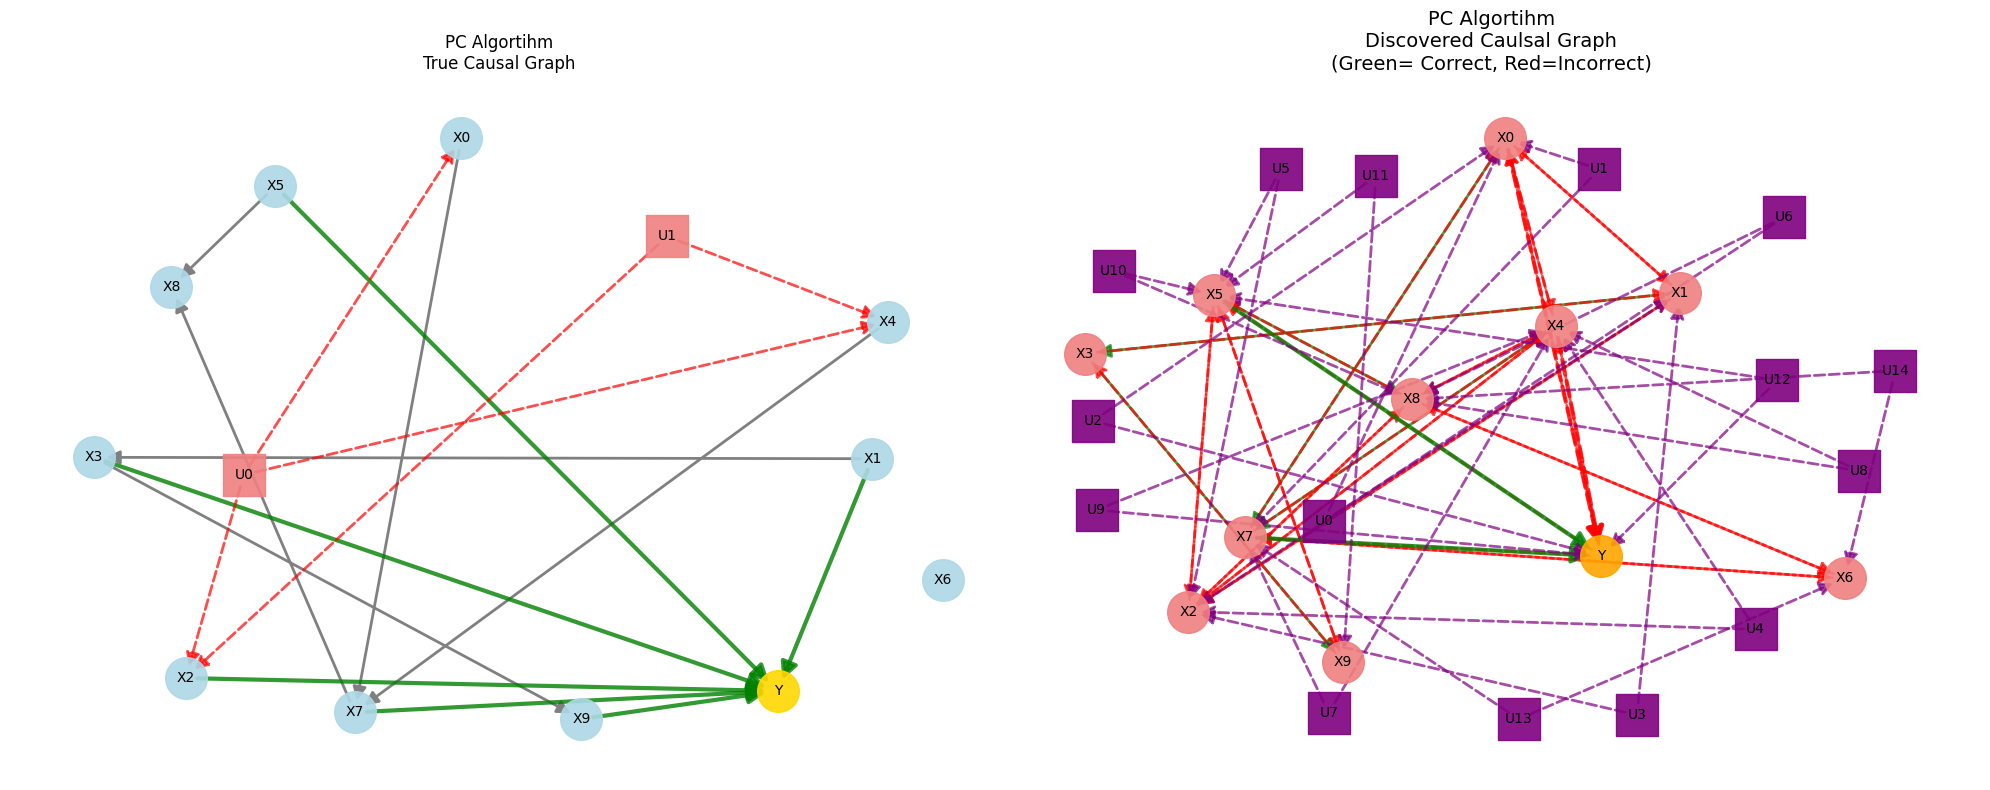

In [90]:
fig_pc=visualize_comparison(true_adj=adj,
                     discovered_adj=results_pc["adjacency_matrix"],
                     features_names=data.columns.tolist(),
                     y_parent_indices=gen_no_linear_conf.y_parent_indices,
                     true_confounders=conf,
                     discovered_confounders=results_pc["confounders"],
                     title_preix='PC Algortihm'
                     )

In [91]:
compare_with_ground_truth( discovered_adj=results_pc["adjacency_matrix"],
                              true_adj=adj,
                              discovered_confounders=results_pc["confounders"],
                              true_confounders=conf)

{'true_positives': 7,
 'false_positives': 31,
 'false_negatives': 5,
 'true_negatives': 78,
 'precision': 0.18421052631578946,
 'recall': 0.5833333333333334,
 'f1_score': 0.27999999999999997,
 'structural_hamming_distance': 36,
 'n_true_edges': 12,
 'n_discovered_edges': 38,
 'n_true_confounders': 2,
 'n_discovered_confounders': 15}

# Model building step

In [92]:
confounder_linear_model = train_predictive_models(
    data,
    y_column='Y',
    models=["lgbm","nn"],
    features_selection=True,
    optimize=True,
    random_state=42
)

Training models to predict Y
Features: 10, Samples: 1000
[1/2] Training LightGBM Regressor
----------------------------------------------------------------------
Optimizing LightGBM hyperparameters (50 trials)...
Training LightGBM model...
[1/2] Training Neural Network Regressor
----------------------------------------------------------------------
Optimizing Neural Network hyperparameters (50 trials)...
dict_keys(['n_layers', 'hidden_dim_0', 'hidden_dim_1', 'hidden_dim_2', 'alpha', 'learning_rate_init', 'batch_size', 'activation'])
Training Neural Network model...
         val_rmse      val_mae    val_r2       val_mse
lgbm  8331.718975  1007.382645  0.396624  6.941754e+07
nn    3099.849063   459.077470  0.916478  9.609064e+06


In [93]:
lgbm_model= confounder_linear_model["models"]["lgbm"]
nn_model = confounder_linear_model["models"]["nn"]

In [94]:
lgbm_model.save(f"../models/{file_path_confounders}_lgbm")
nn_model.save(f"../models/{file_path_confounders}_nn")

LightGBM model saved to ../models/no_linear_conf_low_conectivity_6_parents_10_feats_lgbm.pkl
Neural Network model saved to ../models/no_linear_conf_low_conectivity_6_parents_10_feats_nn.pkl


## Shapley Values - Nonlinear with Confounders

In [96]:
%reload_ext autoreload

In [97]:
X = data.drop(columns=[y_column])
y = data[y_column]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
background_data = X_train.sample(n=int(X_train.shape[0]*0.3), random_state=42)
test_instances = X_val.sample(n=int(X_val.shape[0]*0.5), random_state=42)

# All explainers
shap_explainer = ShapleyExplainer(lgbm_model.model, background_data, method='auto')
shap_values_library = shap_explainer.explain(test_instances)

scratch_explainer = ShapleyFromScratch(lgbm_model.model, background_data, n_samples=100, random_state=42)
shap_values_scratch = scratch_explainer.explain(test_instances, method='monte_carlo')

causal_graph, confounders = pci_fci.discover_structure(X)

asymmetric_explainer = AsymmetricShapley(lgbm_model.model, background_data, causal_graph=causal_graph, n_samples=100, random_sate=42, asymmetric_method='strict')
shap_values_asymmetric = asymmetric_explainer.explain(test_instances, method='exact')

background_data_flow = X_train.copy()
background_data_flow['Y'] = y_train
test_instances_flow = test_instances.copy()
test_instances_flow['Y'] = y_val.sample(n=int(X_val.shape[0]*0.5), random_state=42)

flow_explainer = ShapleyFlowWrapper(model=lgbm_model.model, background_data=background_data_flow, causal_graph=results_pc["adjacency_matrix"], y_index=10, n_samples=100, random_state=42)
shap_values_flow = flow_explainer.explain(test_instances_flow)

causal_explainer = CausalShapley(model=lgbm_model.model, background_data=background_data, discovered_adj=causal_graph, discovered_conf=results_pc["confounders"], feature_names=[x for x in results_pc["feature_names"] if x != 'Y'], n_samples=100, random_state=42)
shap_values_causal = causal_explainer.explain(test_instances)

true_shapley_explainer = TrueShapley(true_generator=gen_no_linear_conf.get_true_y_generator(), background_data=background_data, n_samples=100, random_state=42)
true_shapley_values = true_shapley_explainer.explain(test_instances)

# Comparisons
shap_flat_library = shap_values_library.flatten()
shap_flat_scratch = shap_values_scratch.flatten()
shap_flat_asymmetric = shap_values_asymmetric.flatten()
shap_flat_flow = shap_values_flow.flatten()
shap_flat_causal = shap_values_causal.flatten()
shap_flat_true = true_shapley_values.flatten()

print("Nonlinear System (With Confounders) - Correlations vs Scratch:")
print(f"  Library:    {np.corrcoef(shap_flat_library, shap_flat_scratch)[0,1]:.4f}")
print(f"  Asymmetric: {np.corrcoef(shap_flat_scratch, shap_flat_asymmetric)[0,1]:.4f}")
print(f"  Flow:       {np.corrcoef(shap_flat_scratch, shap_flat_flow)[0,1]:.4f}")
print(f"  Causal:     {np.corrcoef(shap_flat_scratch, shap_flat_causal)[0,1]:.4f}")
print(f"  True:       {np.corrcoef(shap_flat_true, shap_flat_scratch)[0,1]:.4f}")
print("\nMAE vs Scratch:")
print(f"  Library:    {np.abs(shap_flat_library - shap_flat_scratch).mean():.4f}")
print(f"  Asymmetric: {np.abs(shap_flat_asymmetric - shap_flat_scratch).mean():.4f}")
print(f"  Flow:       {np.abs(shap_flat_flow - shap_flat_scratch).mean():.4f}")
print(f"  Causal:     {np.abs(shap_flat_causal - shap_flat_scratch).mean():.4f}")
print(f"  True:       {np.abs(shap_flat_true - shap_flat_scratch).mean():.4f}")

Computing SHAP values using tree explainer...
Computing Shapley values from scratch using monte_carlo method...
 Progress: 10/100 instances
 Progress: 20/100 instances
 Progress: 30/100 instances
 Progress: 40/100 instances
 Progress: 50/100 instances
 Progress: 60/100 instances
 Progress: 70/100 instances
 Progress: 80/100 instances
 Progress: 90/100 instances
 Progress: 100/100 instances
 Running PC algorithm for causal structure discovery...


Depth=4, working on node 9: 100%|██████████| 10/10 [00:00<00:00, 4347.33it/s]


PC discovered 32 edges
 Running FCI algorithm for confounder detection...


Depth=0, working on node 9: 100%|██████████| 10/10 [00:00<00:00, 2634.94it/s]

X1 --> X5
FCI detected 11 potential confounders pairs
Feature X0 has parents: []
Feature X1 has parents: []
Feature X2 has parents: []
Feature X3 has parents: []
Feature X4 has parents: []
Feature X5 has parents: []
Feature X6 has parents: []
Feature X7 has parents: []
Feature X8 has parents: []
Feature X9 has parents: []
Topological order of features: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Using asymmetric method: strict
Computing Causal Shapley values using exact method...
Asymmetric sampling: strict
Respecting causal graph with 32 edges


 Progress: 10/100 instances
 Progress: 20/100 instances
 Progress: 30/100 instances
 Progress: 40/100 instances
 Progress: 50/100 instances
 Progress: 60/100 instances
 Progress: 70/100 instances
 Progress: 80/100 instances
 Progress: 90/100 instances
 Progress: 100/100 instances
ShapleyFlowWrapper initialized:
 Features: 11
 Y index: 10
 Source nodes: [3, 7, 8, 9, 10]
 Edges: 17
 Using on-manifold perturbation with condtional expectatiosn
Computing Shapley Flow for 100 instances...
Computing Shapley Flow with 100 trials...
 Total edge attributions: 14.734624
 Expected (f(x) - f(x')) : 2.395874
 Difference: 12.338750226380725using 100 samples to calculate f(x) and f(x')
 Relative error: 5.1500
Computing Shapley Flow with 100 trials...
 Total edge attributions: 0.000000
 Expected (f(x) - f(x')) : 0.000000
 Difference: 0.0using 100 samples to calculate f(x) and f(x')
 Relative error: 0.0000
Computing Shapley Flow with 100 trials...
 Total edge attributions: 15.070046
 Expected (f(x) - f(

# Mixed relationships

In [98]:
file_path_no_confounders = f"mixed_no_conf_low_conectivity_{int(feats*parents_rate)}_parents_{feats}_feats"

no confounders

In [99]:
gen_mixed_no_conf=SyntheticCausalSystem(n_features=feats,
                                random_state=42,
                                min_num_connected_edges=2,
                                edge_probability=0.1)
data, adj, conf, edge_types  = gen_mixed_no_conf.generate_mixed_system(n_samples=sample,
                                                    with_confounders=False,
                                                    noise_std=0.5,
                                                    linear_ratio=0.5,
                                                    y_parents_ratio=parents_rate)

data.to_parquet(f"../data/{file_path_no_confounders}.parquet")

In [100]:
lingam_fci = LiNGAMWithFCI(alpha=0.05,indep_test="fisherz")
pci_fci = PCWithFCI(alpha=0.5, indep_test="fisherz")
results_lingam = lingam_fci.get_causal_relationships(data)
results_pc = pci_fci.get_causal_relationships(data)

Running LiNGAM algorithm for causal structure discovery...
LiNGAM discovered 16 edges
Running FCI algorithm for confounder detection...


Depth=0, working on node 10: 100%|██████████| 11/11 [00:00<00:00, 2358.52it/s]


FCI detected 1 potential confounders pairs
 Running PC algorithm for causal structure discovery...


Depth=7, working on node 10: 100%|██████████| 11/11 [00:00<00:00, 4725.25it/s]


PC discovered 50 edges
 Running FCI algorithm for confounder detection...


Depth=0, working on node 10: 100%|██████████| 11/11 [00:00<00:00, 2654.32it/s]

FCI detected 22 potential confounders pairs


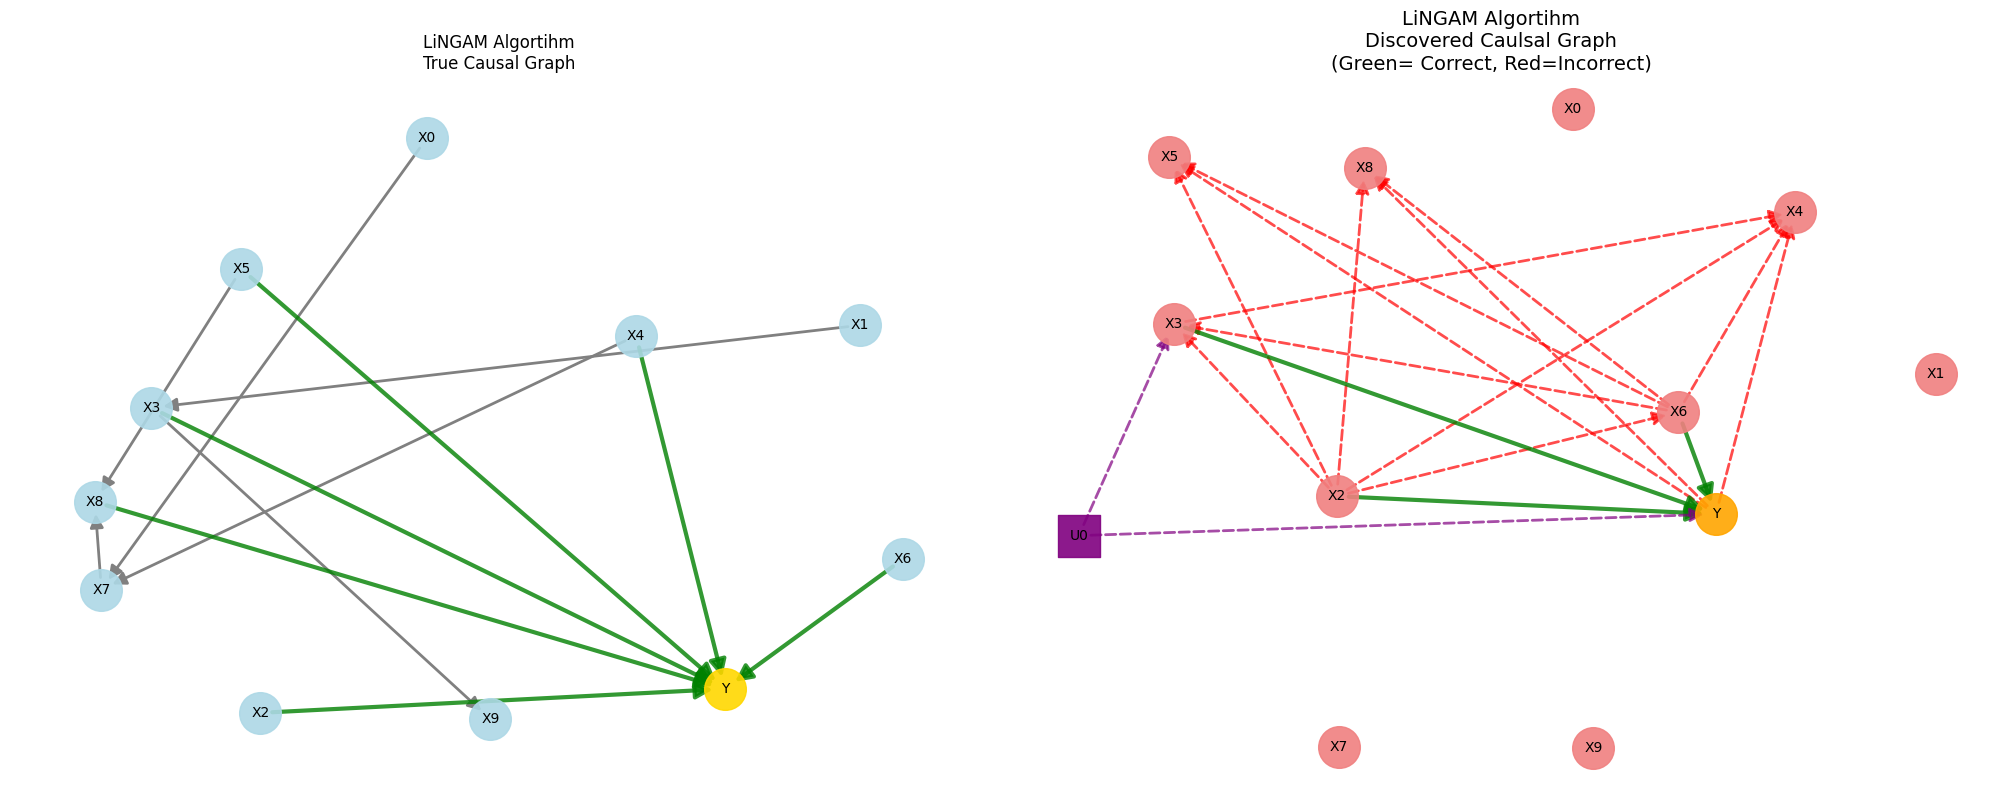

In [101]:
fig_lingam=visualize_comparison(true_adj=adj,
                     discovered_adj=results_lingam["adjacency_matrix"],
                     features_names=data.columns.tolist(),
                     y_parent_indices=gen_mixed_no_conf.y_parent_indices,
                     true_confounders=conf,
                     discovered_confounders=results_lingam["confounders"],
                     title_preix='LiNGAM Algortihm'
                     )

In [102]:
compare_with_ground_truth( discovered_adj=results_lingam["adjacency_matrix"],
                              true_adj=adj,
                              discovered_confounders=results_lingam["confounders"],
                              true_confounders=conf)

{'true_positives': 3,
 'false_positives': 13,
 'false_negatives': 9,
 'true_negatives': 96,
 'precision': 0.1875,
 'recall': 0.25,
 'f1_score': 0.21428571428571427,
 'structural_hamming_distance': 22,
 'n_true_edges': 12,
 'n_discovered_edges': 16,
 'n_true_confounders': 0,
 'n_discovered_confounders': 1}

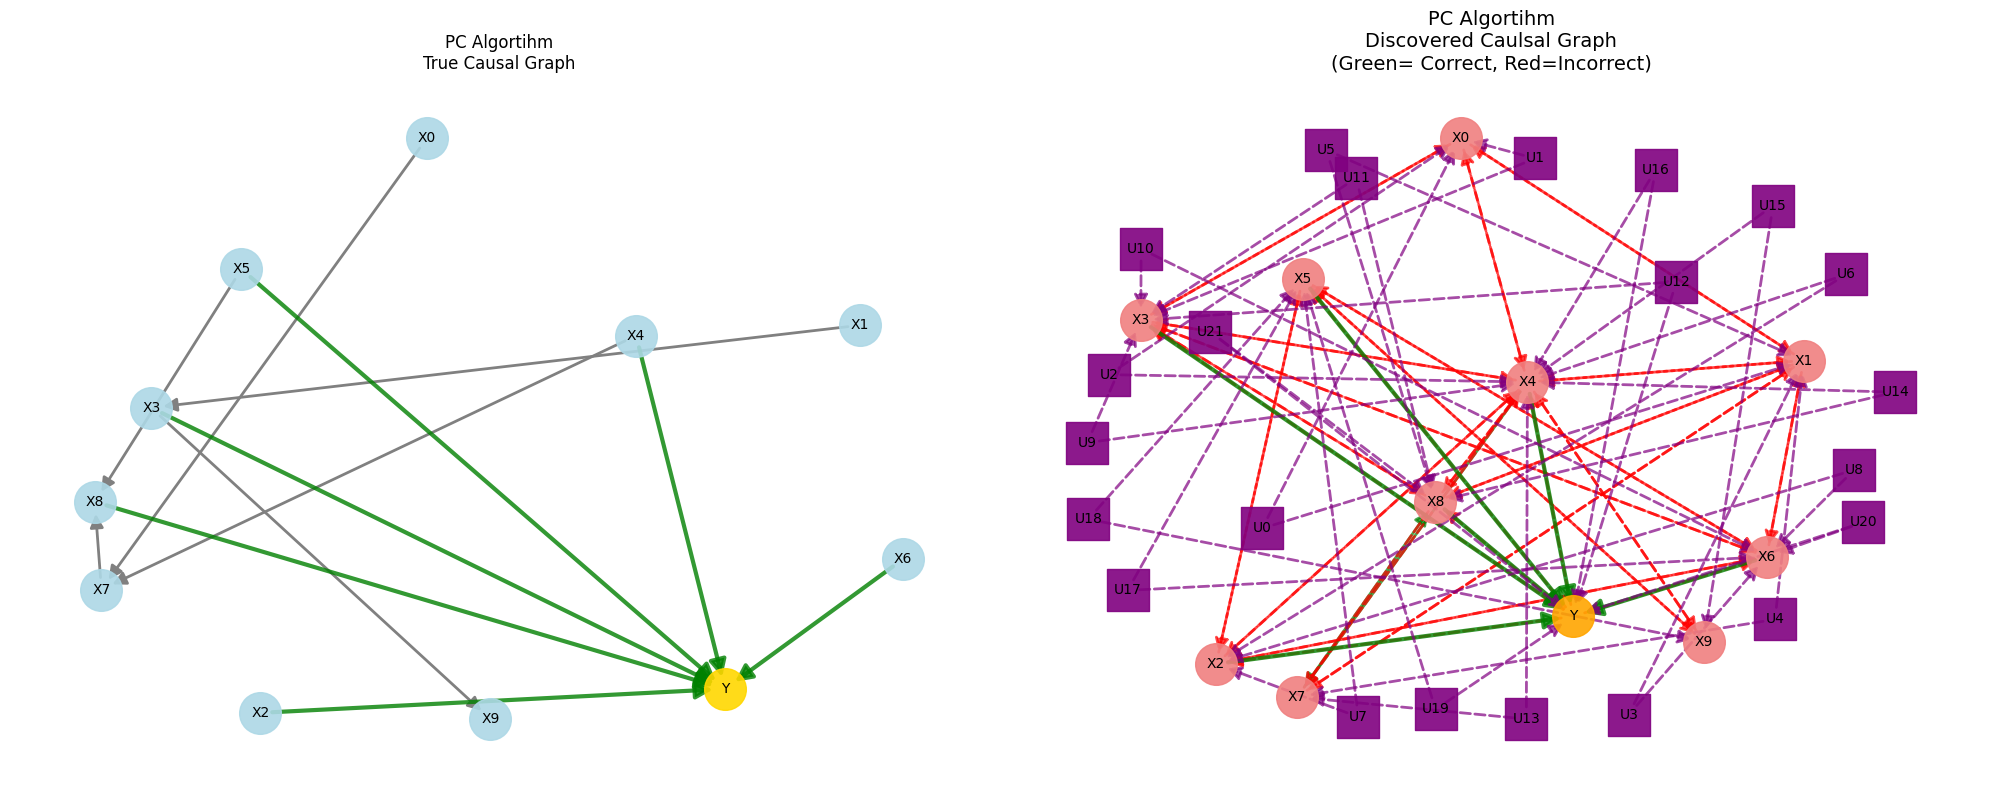

In [103]:
fig_pc=visualize_comparison(true_adj=adj,
                     discovered_adj=results_pc["adjacency_matrix"],
                     features_names=data.columns.tolist(),
                     y_parent_indices=gen_mixed_no_conf.y_parent_indices,
                     true_confounders=conf,
                     discovered_confounders=results_pc["confounders"],
                     title_preix='PC Algortihm'
                     )

In [104]:
compare_with_ground_truth( discovered_adj=results_pc["adjacency_matrix"],
                              true_adj=adj,
                              discovered_confounders=results_pc["confounders"],
                              true_confounders=conf)

{'true_positives': 8,
 'false_positives': 42,
 'false_negatives': 4,
 'true_negatives': 67,
 'precision': 0.16,
 'recall': 0.6666666666666666,
 'f1_score': 0.25806451612903225,
 'structural_hamming_distance': 46,
 'n_true_edges': 12,
 'n_discovered_edges': 50,
 'n_true_confounders': 0,
 'n_discovered_confounders': 22}

# Model building step

In [105]:
no_confounder_linear_model = train_predictive_models(
    data,
    y_column='Y',
    models=["lgbm","nn"],
    features_selection=True,
    optimize=True,
    random_state=42
)

Training models to predict Y
Features: 10, Samples: 1000
[1/2] Training LightGBM Regressor
----------------------------------------------------------------------
Optimizing LightGBM hyperparameters (50 trials)...
Training LightGBM model...
[1/2] Training Neural Network Regressor
----------------------------------------------------------------------
Optimizing Neural Network hyperparameters (50 trials)...
dict_keys(['n_layers', 'hidden_dim_0', 'alpha', 'learning_rate_init', 'batch_size', 'activation'])
Training Neural Network model...
      val_rmse   val_mae    val_r2   val_mse
lgbm  0.543497  0.432663  0.752634  0.295389
nn    0.504369  0.405779  0.786969  0.254388


In [106]:
lgbm_model= no_confounder_linear_model["models"]["lgbm"]
nn_model = no_confounder_linear_model["models"]["nn"]

In [107]:
lgbm_model.save(f"../models/{file_path_no_confounders}_lgbm")
nn_model.save(f"../models/{file_path_no_confounders}_nn")

LightGBM model saved to ../models/mixed_no_conf_low_conectivity_6_parents_10_feats_lgbm.pkl
Neural Network model saved to ../models/mixed_no_conf_low_conectivity_6_parents_10_feats_nn.pkl


## Shapley Values - Mixed without Confounders

In [108]:
X = data.drop(columns=[y_column])
y = data[y_column]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
background_data = X_train.sample(n=int(X_train.shape[0]*0.3), random_state=42)
test_instances = X_val.sample(n=int(X_val.shape[0]*0.5), random_state=42)

# All explainers
shap_explainer = ShapleyExplainer(lgbm_model.model, background_data, method='auto')
shap_values_library = shap_explainer.explain(test_instances)

scratch_explainer = ShapleyFromScratch(lgbm_model.model, background_data, n_samples=100, random_state=42)
shap_values_scratch = scratch_explainer.explain(test_instances, method='monte_carlo')

causal_graph, confounders = pci_fci.discover_structure(X)

asymmetric_explainer = AsymmetricShapley(lgbm_model.model, background_data, causal_graph=causal_graph, n_samples=100, random_sate=42, asymmetric_method='strict')
shap_values_asymmetric = asymmetric_explainer.explain(test_instances, method='exact')

background_data_flow = X_train.copy()
background_data_flow['Y'] = y_train
test_instances_flow = test_instances.copy()
test_instances_flow['Y'] = y_val.sample(n=int(X_val.shape[0]*0.5), random_state=42)

flow_explainer = ShapleyFlowWrapper(model=lgbm_model.model, background_data=background_data_flow, causal_graph=results_pc["adjacency_matrix"], y_index=10, n_samples=100, random_state=42)
shap_values_flow = flow_explainer.explain(test_instances_flow)

causal_explainer = CausalShapley(model=lgbm_model.model, background_data=background_data, discovered_adj=causal_graph, discovered_conf=results_pc["confounders"], feature_names=[x for x in results_pc["feature_names"] if x != 'Y'], n_samples=100, random_state=42)
shap_values_causal = causal_explainer.explain(test_instances)

true_shapley_explainer = TrueShapley(true_generator=gen_mixed_no_conf.get_true_y_generator(), background_data=background_data, n_samples=100, random_state=42)
true_shapley_values = true_shapley_explainer.explain(test_instances)

# Comparisons
shap_flat_library = shap_values_library.flatten()
shap_flat_scratch = shap_values_scratch.flatten()
shap_flat_asymmetric = shap_values_asymmetric.flatten()
shap_flat_flow = shap_values_flow.flatten()
shap_flat_causal = shap_values_causal.flatten()
shap_flat_true = true_shapley_values.flatten()

print("Mixed System (No Confounders) - Correlations vs Scratch:")
print(f"  Library:    {np.corrcoef(shap_flat_library, shap_flat_scratch)[0,1]:.4f}")
print(f"  Asymmetric: {np.corrcoef(shap_flat_scratch, shap_flat_asymmetric)[0,1]:.4f}")
print(f"  Flow:       {np.corrcoef(shap_flat_scratch, shap_flat_flow)[0,1]:.4f}")
print(f"  Causal:     {np.corrcoef(shap_flat_scratch, shap_flat_causal)[0,1]:.4f}")
print(f"  True:       {np.corrcoef(shap_flat_true, shap_flat_scratch)[0,1]:.4f}")
print("\nMAE vs Scratch:")
print(f"  Library:    {np.abs(shap_flat_library - shap_flat_scratch).mean():.4f}")
print(f"  Asymmetric: {np.abs(shap_flat_asymmetric - shap_flat_scratch).mean():.4f}")
print(f"  Flow:       {np.abs(shap_flat_flow - shap_flat_scratch).mean():.4f}")
print(f"  Causal:     {np.abs(shap_flat_causal - shap_flat_scratch).mean():.4f}")
print(f"  True:       {np.abs(shap_flat_true - shap_flat_scratch).mean():.4f}")

Computing SHAP values using tree explainer...
Computing Shapley values from scratch using monte_carlo method...
 Progress: 10/100 instances
 Progress: 20/100 instances
 Progress: 30/100 instances
 Progress: 40/100 instances
 Progress: 50/100 instances
 Progress: 60/100 instances
 Progress: 70/100 instances
 Progress: 80/100 instances
 Progress: 90/100 instances
 Progress: 100/100 instances
 Running PC algorithm for causal structure discovery...


Depth=6, working on node 9: 100%|██████████| 10/10 [00:00<00:00, 5285.16it/s]


PC discovered 44 edges
 Running FCI algorithm for confounder detection...


Depth=0, working on node 9: 100%|██████████| 10/10 [00:00<00:00, 2769.25it/s]

FCI detected 18 potential confounders pairs
Feature X0 has parents: ['X1', 'X3', 'X4', 'X6']
Feature X1 has parents: ['X8', 'X4', 'X6', 'X7']
Feature X2 has parents: ['X8', 'X4', 'X5', 'X6']
Feature X3 has parents: ['X8', 'X4', 'X5', 'X6']
Feature X4 has parents: ['X8', 'X9', 'X7']
Feature X5 has parents: ['X9', 'X6']
Feature X6 has parents: []
Feature X7 has parents: []
Feature X8 has parents: []
Feature X9 has parents: []
Topological order of features: [6, 7, 8, 9, 4, 1, 5, 2, 3, 0]
Using asymmetric method: strict
Computing Causal Shapley values using exact method...
Asymmetric sampling: strict
Respecting causal graph with 44 edges


 Progress: 10/100 instances
 Progress: 20/100 instances
 Progress: 30/100 instances
 Progress: 40/100 instances
 Progress: 50/100 instances
 Progress: 60/100 instances
 Progress: 70/100 instances
 Progress: 80/100 instances
 Progress: 90/100 instances
 Progress: 100/100 instances
ShapleyFlowWrapper initialized:
 Features: 11
 Y index: 10
 Source nodes: [6, 7, 9]
 Edges: 25
 Using on-manifold perturbation with condtional expectatiosn
Computing Shapley Flow for 100 instances...
Computing Shapley Flow with 100 trials...
 Total edge attributions: 5.691135
 Expected (f(x) - f(x')) : 1.640496
 Difference: 4.05063834977838 using 100 samples to calculate f(x) and f(x')
 Relative error: 2.4692
Computing Shapley Flow with 100 trials...
 Total edge attributions: 1.771819
 Expected (f(x) - f(x')) : 0.082354
 Difference: 1.689465829613067 using 100 samples to calculate f(x) and f(x')
 Relative error: 20.5148
Computing Shapley Flow with 100 trials...
 Total edge attributions: 0.303993
 Expected (f(x

Confounders present

In [109]:
file_path_confounders = f"mixed_conf_low_conectivity_{int(feats*parents_rate)}_parents_{feats}_feats"

In [110]:
gen_mixed_conf=SyntheticCausalSystem(n_features=feats,
                                random_state=42,
                                min_num_connected_edges=2,
                                edge_probability=0.1)
data, adj, conf, edge_types  = gen_mixed_conf.generate_mixed_system(n_samples=sample,
                                                    with_confounders=True,
                                                    noise_std=0.5,
                                                    linear_ratio=0.5,
                                                    y_parents_ratio=parents_rate)

data.to_parquet(f"../data/{file_path_confounders}.parquet")

In [111]:
lingam_fci = LiNGAMWithFCI(alpha=0.05,indep_test="fisherz")
pci_fci = PCWithFCI(alpha=0.5, indep_test="fisherz")
results_lingam = lingam_fci.get_causal_relationships(data)
results_pc = pci_fci.get_causal_relationships(data)

Running LiNGAM algorithm for causal structure discovery...
LiNGAM discovered 7 edges
Running FCI algorithm for confounder detection...


Depth=0, working on node 10: 100%|██████████| 11/11 [00:00<00:00, 2394.51it/s]


FCI detected 3 potential confounders pairs
 Running PC algorithm for causal structure discovery...


Depth=4, working on node 10: 100%|██████████| 11/11 [00:00<00:00, 3514.16it/s]


PC discovered 38 edges
 Running FCI algorithm for confounder detection...


Depth=0, working on node 10: 100%|██████████| 11/11 [00:00<00:00, 2648.22it/s]

X5 --> X8
X5 --> X9
X8 --> X7
FCI detected 12 potential confounders pairs


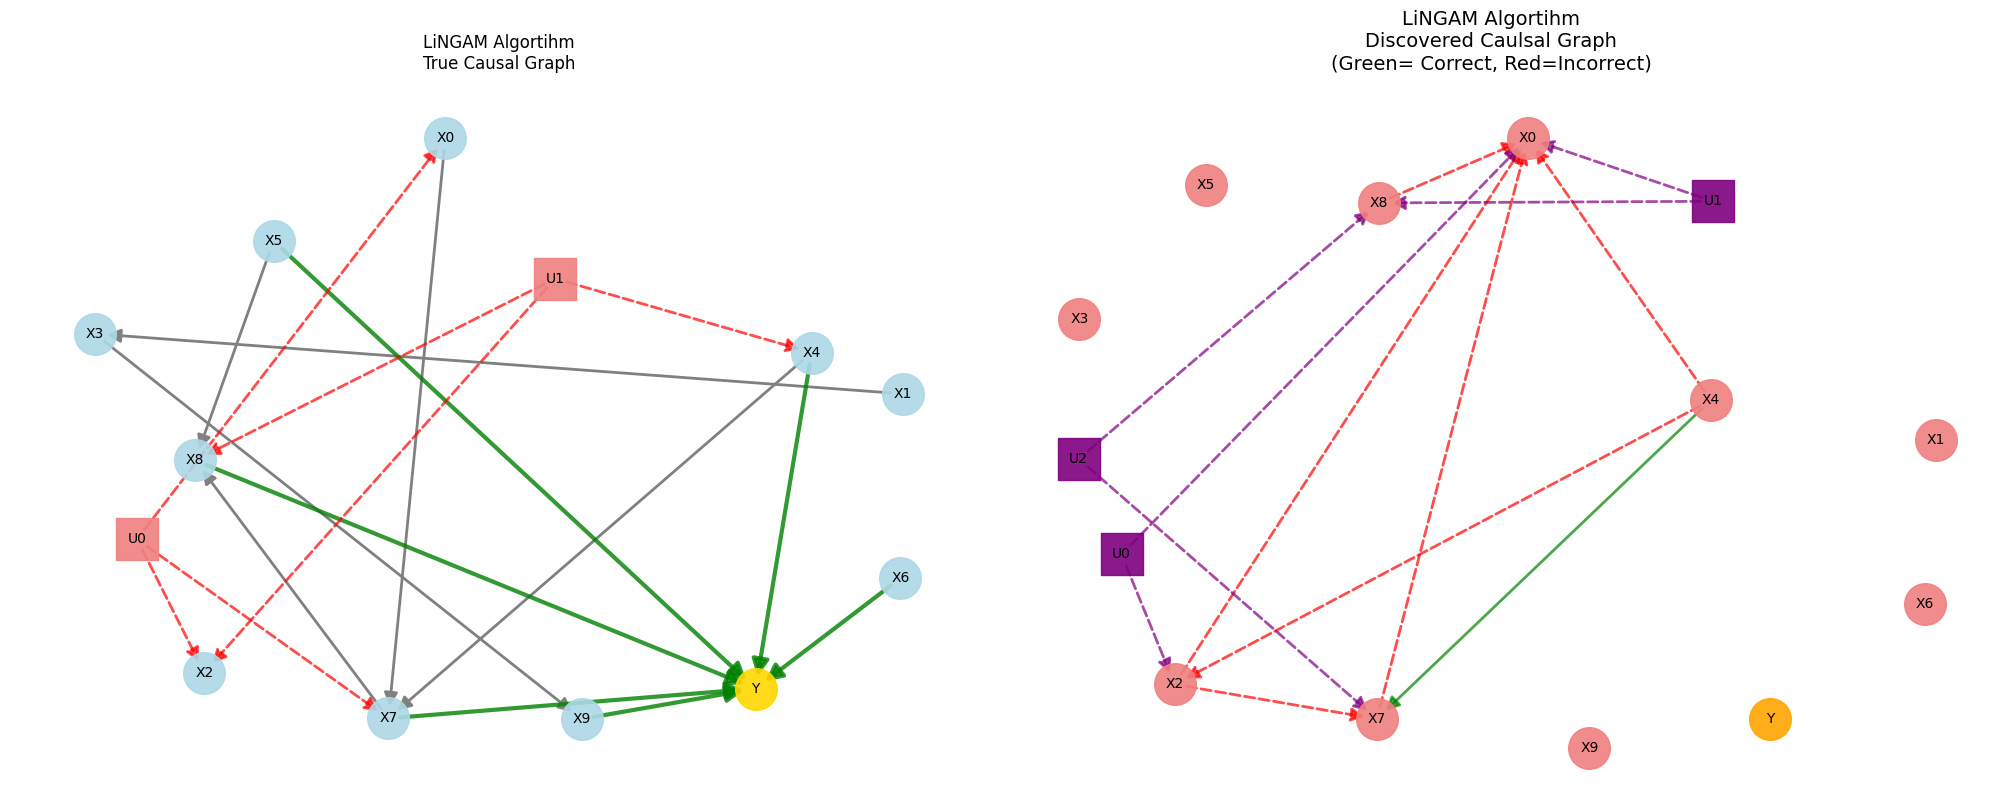

In [112]:
fig_lingam=visualize_comparison(true_adj=adj,
                     discovered_adj=results_lingam["adjacency_matrix"],
                     features_names=data.columns.tolist(),
                     y_parent_indices=gen_mixed_conf.y_parent_indices,
                     true_confounders=conf,
                     discovered_confounders=results_lingam["confounders"],
                     title_preix='LiNGAM Algortihm'
                     )

In [113]:
compare_with_ground_truth( discovered_adj=results_lingam["adjacency_matrix"],
                              true_adj=adj,
                              discovered_confounders=results_lingam["confounders"],
                              true_confounders=conf)

{'true_positives': 1,
 'false_positives': 6,
 'false_negatives': 11,
 'true_negatives': 103,
 'precision': 0.14285714285714285,
 'recall': 0.08333333333333333,
 'f1_score': 0.10526315789473685,
 'structural_hamming_distance': 17,
 'n_true_edges': 12,
 'n_discovered_edges': 7,
 'n_true_confounders': 2,
 'n_discovered_confounders': 3}

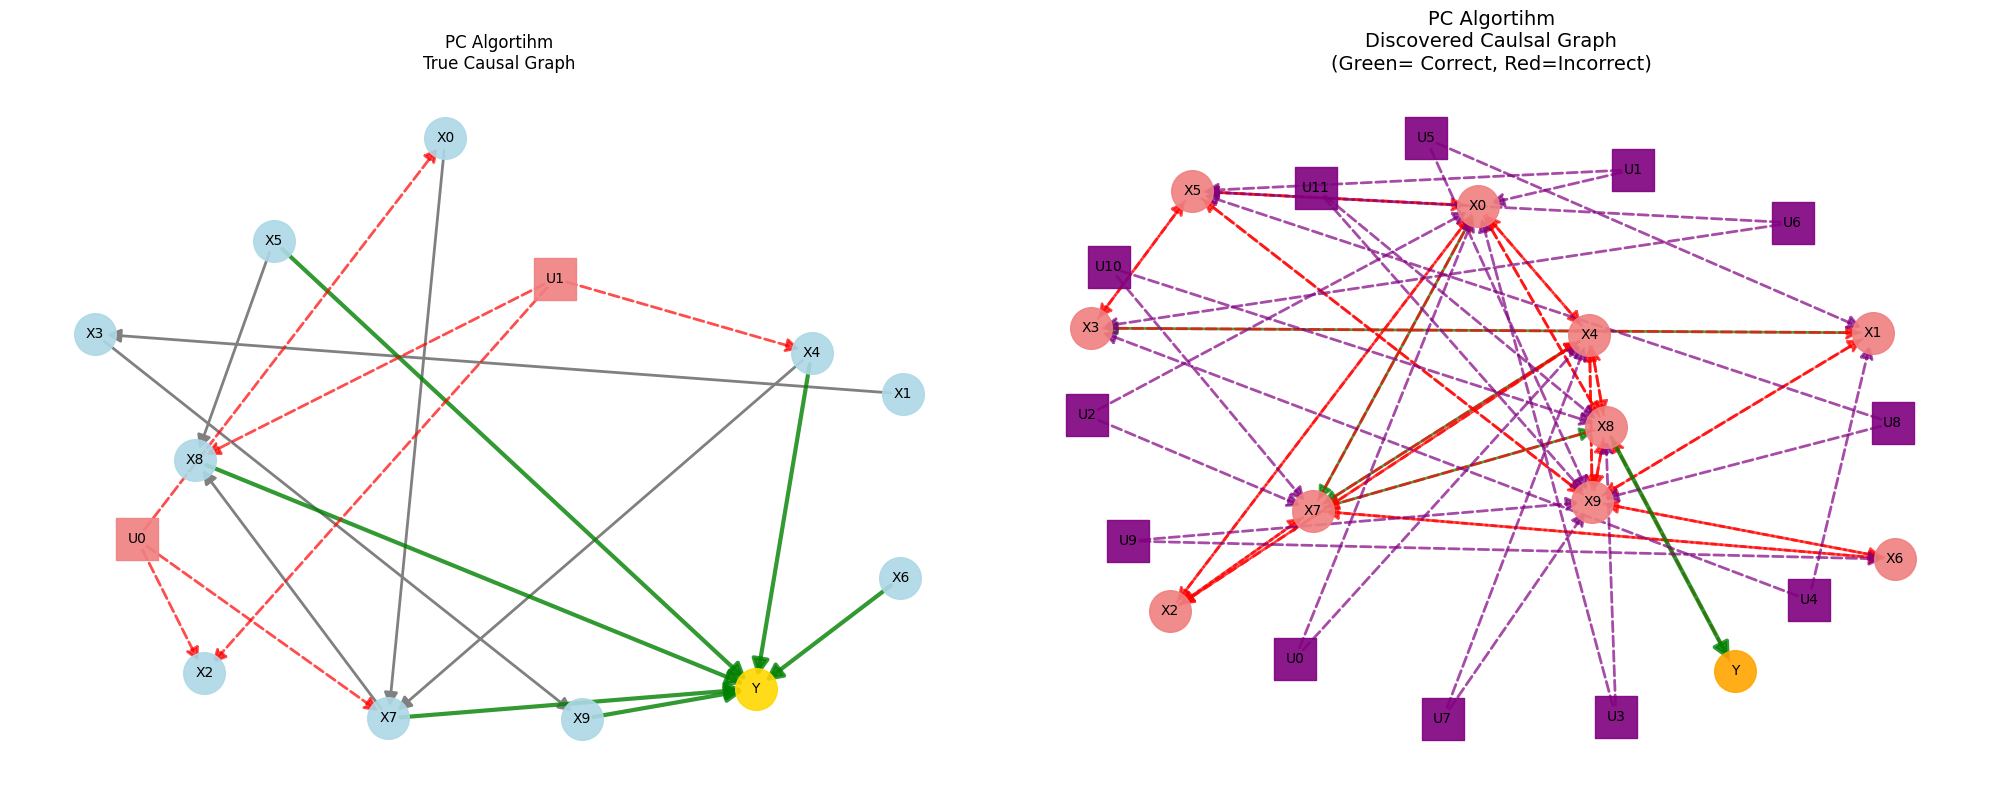

In [114]:
fig_pc=visualize_comparison(true_adj=adj,
                     discovered_adj=results_pc["adjacency_matrix"],
                     features_names=data.columns.tolist(),
                     y_parent_indices=gen_mixed_conf.y_parent_indices,
                     true_confounders=conf,
                     discovered_confounders=results_pc["confounders"],
                     title_preix='PC Algortihm'
                     )

In [115]:
compare_with_ground_truth( discovered_adj=results_pc["adjacency_matrix"],
                              true_adj=adj,
                              discovered_confounders=results_pc["confounders"],
                              true_confounders=conf)

{'true_positives': 5,
 'false_positives': 33,
 'false_negatives': 7,
 'true_negatives': 76,
 'precision': 0.13157894736842105,
 'recall': 0.4166666666666667,
 'f1_score': 0.19999999999999998,
 'structural_hamming_distance': 40,
 'n_true_edges': 12,
 'n_discovered_edges': 38,
 'n_true_confounders': 2,
 'n_discovered_confounders': 12}

# Model building step

In [116]:
confounder_linear_model = train_predictive_models(
    data,
    y_column='Y',
    models=["lgbm","nn"],
    features_selection=True,
    optimize=True,
    random_state=42
)

Training models to predict Y
Features: 10, Samples: 1000
[1/2] Training LightGBM Regressor
----------------------------------------------------------------------
Optimizing LightGBM hyperparameters (50 trials)...
Training LightGBM model...
[1/2] Training Neural Network Regressor
----------------------------------------------------------------------
Optimizing Neural Network hyperparameters (50 trials)...
dict_keys(['n_layers', 'hidden_dim_0', 'hidden_dim_1', 'hidden_dim_2', 'alpha', 'learning_rate_init', 'batch_size', 'activation'])
Training Neural Network model...
           val_rmse       val_mae    val_r2       val_mse
lgbm  249831.645775  28305.318227  0.311773  6.241585e+10
nn     96165.472194   9726.082186  0.898029  9.247798e+09


In [117]:
lgbm_model= confounder_linear_model["models"]["lgbm"]
nn_model = confounder_linear_model["models"]["nn"]

In [118]:
lgbm_model.save(f"../models/{file_path_confounders}_lgbm")
nn_model.save(f"../models/{file_path_confounders}_nn")

LightGBM model saved to ../models/mixed_conf_low_conectivity_6_parents_10_feats_lgbm.pkl
Neural Network model saved to ../models/mixed_conf_low_conectivity_6_parents_10_feats_nn.pkl


## Shapley Values - Mixed with Confounders

In [119]:
X = data.drop(columns=[y_column])
y = data[y_column]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
background_data = X_train.sample(n=int(X_train.shape[0]*0.3), random_state=42)
test_instances = X_val.sample(n=int(X_val.shape[0]*0.5), random_state=42)

# All explainers
shap_explainer = ShapleyExplainer(lgbm_model.model, background_data, method='auto')
shap_values_library = shap_explainer.explain(test_instances)

scratch_explainer = ShapleyFromScratch(lgbm_model.model, background_data, n_samples=100, random_state=42)
shap_values_scratch = scratch_explainer.explain(test_instances, method='monte_carlo')

causal_graph, confounders = pci_fci.discover_structure(X)

asymmetric_explainer = AsymmetricShapley(lgbm_model.model, background_data, causal_graph=causal_graph, n_samples=100, random_sate=42, asymmetric_method='strict')
shap_values_asymmetric = asymmetric_explainer.explain(test_instances, method='exact')

background_data_flow = X_train.copy()
background_data_flow['Y'] = y_train
test_instances_flow = test_instances.copy()
test_instances_flow['Y'] = y_val.sample(n=int(X_val.shape[0]*0.5), random_state=42)

flow_explainer = ShapleyFlowWrapper(model=lgbm_model.model, background_data=background_data_flow, causal_graph=results_pc["adjacency_matrix"], y_index=10, n_samples=100, random_state=42)
shap_values_flow = flow_explainer.explain(test_instances_flow)

causal_explainer = CausalShapley(model=lgbm_model.model, background_data=background_data, discovered_adj=causal_graph, discovered_conf=results_pc["confounders"], feature_names=[x for x in results_pc["feature_names"] if x != 'Y'], n_samples=100, random_state=42)
shap_values_causal = causal_explainer.explain(test_instances)

true_shapley_explainer = TrueShapley(true_generator=gen_mixed_conf.get_true_y_generator(), background_data=background_data, n_samples=100, random_state=42)
true_shapley_values = true_shapley_explainer.explain(test_instances)

# Comparisons
shap_flat_library = shap_values_library.flatten()
shap_flat_scratch = shap_values_scratch.flatten()
shap_flat_asymmetric = shap_values_asymmetric.flatten()
shap_flat_flow = shap_values_flow.flatten()
shap_flat_causal = shap_values_causal.flatten()
shap_flat_true = true_shapley_values.flatten()

print("Mixed System (With Confounders) - Correlations vs Scratch:")
print(f"  Library:    {np.corrcoef(shap_flat_library, shap_flat_scratch)[0,1]:.4f}")
print(f"  Asymmetric: {np.corrcoef(shap_flat_scratch, shap_flat_asymmetric)[0,1]:.4f}")
print(f"  Flow:       {np.corrcoef(shap_flat_scratch, shap_flat_flow)[0,1]:.4f}")
print(f"  Causal:     {np.corrcoef(shap_flat_scratch, shap_flat_causal)[0,1]:.4f}")
print(f"  True:       {np.corrcoef(shap_flat_true, shap_flat_scratch)[0,1]:.4f}")
print("\nMAE vs Scratch:")
print(f"  Library:    {np.abs(shap_flat_library - shap_flat_scratch).mean():.4f}")
print(f"  Asymmetric: {np.abs(shap_flat_asymmetric - shap_flat_scratch).mean():.4f}")
print(f"  Flow:       {np.abs(shap_flat_flow - shap_flat_scratch).mean():.4f}")
print(f"  Causal:     {np.abs(shap_flat_causal - shap_flat_scratch).mean():.4f}")
print(f"  True:       {np.abs(shap_flat_true - shap_flat_scratch).mean():.4f}")

Computing SHAP values using tree explainer...
Computing Shapley values from scratch using monte_carlo method...
 Progress: 10/100 instances
 Progress: 20/100 instances
 Progress: 30/100 instances
 Progress: 40/100 instances
 Progress: 50/100 instances
 Progress: 60/100 instances
 Progress: 70/100 instances
 Progress: 80/100 instances
 Progress: 90/100 instances
 Progress: 100/100 instances
 Running PC algorithm for causal structure discovery...


Depth=4, working on node 9: 100%|██████████| 10/10 [00:00<00:00, 3652.30it/s]


PC discovered 36 edges
 Running FCI algorithm for confounder detection...


Depth=0, working on node 9: 100%|██████████| 10/10 [00:00<00:00, 2230.18it/s]

X5 --> X8
X5 --> X9
X8 --> X7
X9 --> X8
FCI detected 11 potential confounders pairs
Feature X0 has parents: ['X2', 'X4', 'X5', 'X7', 'X8']
Feature X1 has parents: ['X9', 'X3']
Feature X2 has parents: []
Feature X3 has parents: []
Feature X4 has parents: ['X9', 'X2']
Feature X5 has parents: ['X9', 'X3']
Feature X6 has parents: ['X9', 'X7']
Feature X7 has parents: ['X8', 'X2', 'X4']
Feature X8 has parents: ['X9', 'X4']
Feature X9 has parents: []
Topological order of features: [2, 3, 9, 1, 4, 5, 8, 7, 0, 6]
Using asymmetric method: strict
Computing Causal Shapley values using exact method...
Asymmetric sampling: strict
Respecting causal graph with 36 edges


 Progress: 10/100 instances
 Progress: 20/100 instances
 Progress: 30/100 instances
 Progress: 40/100 instances
 Progress: 50/100 instances
 Progress: 60/100 instances
 Progress: 70/100 instances
 Progress: 80/100 instances
 Progress: 90/100 instances
 Progress: 100/100 instances
ShapleyFlowWrapper initialized:
 Features: 11
 Y index: 10
 Source nodes: [2, 3, 9, 10]
 Edges: 19
 Using on-manifold perturbation with condtional expectatiosn
Computing Shapley Flow for 100 instances...
Computing Shapley Flow with 100 trials...
 Total edge attributions: 708.323287
 Expected (f(x) - f(x')) : 224.152939
 Difference: 484.17034791729736 using 100 samples to calculate f(x) and f(x')
 Relative error: 2.1600
Computing Shapley Flow with 100 trials...
 Total edge attributions: -5124.064242
 Expected (f(x) - f(x')) : -4499.262164
 Difference: 624.8020784274195 using 100 samples to calculate f(x) and f(x')
 Relative error: 0.1389
Computing Shapley Flow with 100 trials...
 Total edge attributions: 694.87

## Summary - All Systems Complete

All synthetic data systems (6 total) now have complete Shapley value analysis:

1. **Linear without Confounders** ✓
2. **Linear with Confounders** ✓  
3. **Nonlinear without Confounders** ✓
4. **Nonlinear with Confounders** ✓
5. **Mixed without Confounders** ✓
6. **Mixed with Confounders** ✓  

Each system includes:
- Standard SHAP (library)
- Shapley from Scratch (Monte Carlo)
- Asymmetric Shapley (causal constraints)
- Shapley Flow (graph-based)
- Causal Shapley (post-interventional)
- **True Shapley (ground truth)**